# Project: Identify Customer Segments

In this project, you will apply unsupervised learning techniques to identify segments of the population that form the core customer base for a mail-order sales company in Germany. These segments can then be used to direct marketing campaigns towards audiences that will have the highest expected rate of returns. The data that you will use has been provided by our partners at Bertelsmann Arvato Analytics, and represents a real-life data science task.

This notebook will help you complete this task by providing a framework within which you will perform your analysis steps. In each step of the project, you will see some text describing the subtask that you will perform, followed by one or more code cells for you to complete your work. **Feel free to add additional code and markdown cells as you go along so that you can explore everything in precise chunks.** The code cells provided in the base template will outline only the major tasks, and will usually not be enough to cover all of the minor tasks that comprise it.

It should be noted that while there will be precise guidelines on how you should handle certain tasks in the project, there will also be places where an exact specification is not provided. **There will be times in the project where you will need to make and justify your own decisions on how to treat the data.** These are places where there may not be only one way to handle the data. In real-life tasks, there may be many valid ways to approach an analysis task. One of the most important things you can do is clearly document your approach so that other scientists can understand the decisions you've made.

At the end of most sections, there will be a Markdown cell labeled **Discussion**. In these cells, you will report your findings for the completed section, as well as document the decisions that you made in your approach to each subtask. **Your project will be evaluated not just on the code used to complete the tasks outlined, but also your communication about your observations and conclusions at each stage.**

In [2]:
# import libraries here; add more as necessary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (OneHotEncoder, StandardScaler, FunctionTransformer, OrdinalEncoder)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn import set_config

from pprint import pprint
import json
import gc

import random
import copy

from IPython.display import display, HTML

# magic word for producing visualizations in notebook
%matplotlib inline

pd.options.display.max_rows = None
pd.options.display.max_columns = None
random.seed(42)

# So that our sklearn estimators/transformers output a pandas dataframe
set_config(transform_output="pandas")

Here I define constants that I will use, that way I avoid hard-coding strings:

In [3]:
# CONSTANTS
# Feature Types
BINARY = "binary"
BIN_NO_NUM = "non_numeric_binary"
NUMERIC = "numeric"
ORDINAL = "ordinal"
INTERVAL = "interval"

CATEGORICAL = "categorical"
MULTI = "multi_categorical"
MIXED = "mixed"

ENGINEERED_FEATURES = "engineered_features"
ENCODED_FEATURES = "encoded_features"

# For feature actions
TO_ENGINEER = "features_to_engineer"
TO_DROP = "features_to_drop"
TO_KEEP = "features_to_keep"
TO_SCALE = "features_to_scale"

# Re-encoded feature
OST_WEST = 'OST_WEST_KZ'

# Features to engineer
PRA_JUG = 'PRAEGENDE_JUGENDJAHRE'
CAM_INT = 'CAMEO_INTL_2015'
WOHN = 'WOHNLAGE'
LP_LEB = 'LP_LEBENSPHASE_FEIN'

# Engineered (new) features
P_DECADE = 'PRAEGENDE_DECADE'
P_MOVEMENT = 'PRAEGENDE_MOVEMENT'

C_WEALTH = 'CAMEO_WEALTH'
C_LIFE = 'CAMEO_LIFESTAGE'

WOHN_QUAL = 'WOHN_NEIGHBORHOOD_QUALITY'
WOHN_RURAL = 'WOHN_IS_RURAL'
WOHN_BUILD = 'WOHN_NEW_BUILDING'

LP_STAGE = 'LP_LIFE_STAGE'
LP_INCOME = 'LP_INCOME_LEVEL'
LP_AGE = 'LP_AGE_CLASS'
LP_HOMEOWN = 'LP_IS_HOMEOWNER'
LP_INDEP = 'LP_IS_INDEPENDENT'

# Data filenames
DATA_AZDIAS = "Udacity_AZDIAS_Subset.csv"
DATA_CUSTOMERS = "Udacity_CUSTOMERS_Subset.csv"
DATA_F_SUMMARY = "AZDIAS_Feature_Summary.csv"
DATA_DICT = "data_dictionary.json"

# FEATURE SUMMARY COLUMN LABLES
FS_TYPE = "type"
FS_ATTR = "attribute"
FS_OBJ = "object"
FS_MISS_UNKWN = "missing_or_unknown"

# FEATURES REMOVED BY COLUMN THRESHOLD
NA_FEATURES = "na_features"

In [4]:
# GENERAL VARIABLES TO BE USED THROUGHOUT THE NOTEBOOK

# For keeping track of the expected number of features (for sanity check later)
expected_n_features = 0

# For organizing features into groups to guide the preprocessing pipeline
# Initialized
feature_groups = {
    BINARY: [],
    BIN_NO_NUM: [],
    ORDINAL: [],
    NUMERIC: [],
    INTERVAL: [],
    MULTI: [],
    ENGINEERED_FEATURES: [],
    ENCODED_FEATURES: [],
    TO_ENGINEER: [],
    TO_SCALE: [],
    TO_DROP: {
        CATEGORICAL: [],
        NA_FEATURES: [],
        MIXED: []
    }
}

# For organizing mappings
# Create a dict for each original feature, so we can iterate
mappings = {
    PRA_JUG: {},
    CAM_INT: {}, # Will be empty, we calculate
    LP_LEB: {},
    WOHN: {}
}

# For the feature dictionary
feature_dictionary = {}

# For keeping track of the prominent features
# PC1, PC2 and PC3
prominent_features = {0: {}, 1: {}, 2: {}}

### Step 0: Load the Data

There are four files associated with this project (not including this one):

- `Udacity_AZDIAS_Subset.csv`: Demographics data for the general population of Germany; 891211 persons (rows) x 85 features (columns).
- `Udacity_CUSTOMERS_Subset.csv`: Demographics data for customers of a mail-order company; 191652 persons (rows) x 85 features (columns).
- `Data_Dictionary.md`: Detailed information file about the features in the provided datasets.
- `AZDIAS_Feature_Summary.csv`: Summary of feature attributes for demographics data; 85 features (rows) x 4 columns

Each row of the demographics files represents a single person, but also includes information outside of individuals, including information about their household, building, and neighborhood. You will use this information to cluster the general population into groups with similar demographic properties. Then, you will see how the people in the customers dataset fit into those created clusters. The hope here is that certain clusters are over-represented in the customers data, as compared to the general population; those over-represented clusters will be assumed to be part of the core userbase. This information can then be used for further applications, such as targeting for a marketing campaign.

To start off with, load in the demographics data for the general population into a pandas DataFrame, and do the same for the feature attributes summary. Note for all of the `.csv` data files in this project: they're semicolon (`;`) delimited, so you'll need an additional argument in your [`read_csv()`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.read_csv.html) call to read in the data properly. Also, considering the size of the main dataset, it may take some time for it to load completely.

Once the dataset is loaded, it's recommended that you take a little bit of time just browsing the general structure of the dataset and feature summary file. You'll be getting deep into the innards of the cleaning in the first major step of the project, so gaining some general familiarity can help you get your bearings.

In [5]:
# Load in the general demographics data.
df_population_raw = pd.read_csv(DATA_AZDIAS, delimiter=';')

# Load in the feature summary file.
feature_summary = pd.read_csv(DATA_F_SUMMARY, delimiter=';')

#### Step 0.1.1: General Population Data:

In [6]:
# Check the structure of the data after it's loaded (e.g. print the number of
# rows and columns, print the first few rows).
population_rows, population_cols = df_population_raw.shape
print(f"Population rows: {population_rows}")
print(f"Population columns: {population_cols}")

# As we start with 85 columns, we update the expected number of features
expected_n_features = population_cols

Population rows: 891221
Population columns: 85


In [7]:
# Info
df_population_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891221 entries, 0 to 891220
Data columns (total 85 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AGER_TYP               891221 non-null  int64  
 1   ALTERSKATEGORIE_GROB   891221 non-null  int64  
 2   ANREDE_KZ              891221 non-null  int64  
 3   CJT_GESAMTTYP          886367 non-null  float64
 4   FINANZ_MINIMALIST      891221 non-null  int64  
 5   FINANZ_SPARER          891221 non-null  int64  
 6   FINANZ_VORSORGER       891221 non-null  int64  
 7   FINANZ_ANLEGER         891221 non-null  int64  
 8   FINANZ_UNAUFFAELLIGER  891221 non-null  int64  
 9   FINANZ_HAUSBAUER       891221 non-null  int64  
 10  FINANZTYP              891221 non-null  int64  
 11  GEBURTSJAHR            891221 non-null  int64  
 12  GFK_URLAUBERTYP        886367 non-null  float64
 13  GREEN_AVANTGARDE       891221 non-null  int64  
 14  HEALTH_TYP             891221 non-nu

In [8]:
# View some rows
df_population_raw.head()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,-1,2,1,2.0,3,4,3,5,5,3,4,0,10.0,0,-1,15.0,4.0,2.0,2.0,1.0,1.0,0,0,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,-1,NaN,NaN,-1,3,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,1,2,5.0,1,5,2,5,4,5,1,1996,10.0,0,3,21.0,6.0,5.0,3.0,2.0,1.0,1,14,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3,1.0,0.0,2,5,0.0,2.0,0.0,6.0,NaN,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,5.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,-1,3,2,3.0,1,4,1,2,3,5,1,1979,10.0,1,3,3.0,1.0,1.0,1.0,3.0,2.0,1,15,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2,0.0,0.0,1,5,17.0,1.0,0.0,4.0,NaN,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,2,4,2,2.0,4,2,5,2,1,2,6,1957,1.0,0,2,0.0,0.0,0.0,0.0,9.0,4.0,1,8,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1,0.0,0.0,1,3,13.0,0.0,0.0,1.0,NaN,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2,2A,12,4.0,1.0,0.0,0.0,1.0,4.0,4.0,2.0,6.0,4.0,0.0,4.0,1.0,0.0,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,-1,3,1,5.0,4,3,4,1,3,2,5,1963,5.0,0,3,32.0,10.0,10.0,5.0,3.0,2.0,1,8,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2,0.0,0.0,2,4,20.0,4.0,0.0,5.0,1.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6,6B,43,1.0,4.0,1.0,0.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


In [9]:
# data types
df_population_raw.dtypes.value_counts()

float64    49
int64      32
object      4
Name: count, dtype: int64

So basic information about the general population demographics data:
- There are 891,221 entries/samples, or rows, each representing one person
- There are a total of 85 rows or features
- There are 81 numeric features (32xint64 + 49xfloat64) and 4 non-numeric features (objects)

#### Step 0.1.2: Feature Summary

In [10]:
# Show some rows
feature_summary.head()

,attribute,information_level,type,missing_or_unknown
0,AGER_TYP,person,categorical,"[-1,0]"
1,ALTERSKATEGORIE_GROB,person,ordinal,"[-1,0,9]"
2,ANREDE_KZ,person,categorical,"[-1,0]"
3,CJT_GESAMTTYP,person,categorical,[0]
4,FINANZ_MINIMALIST,person,ordinal,[-1]


In [11]:
# Info
feature_summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   attribute           85 non-null     object
 1   information_level   85 non-null     object
 2   type                85 non-null     object
 3   missing_or_unknown  85 non-null     object
dtypes: object(4)
memory usage: 2.8+ KB


In [12]:
# Explore the 'type' column. Get the counts
feature_summary['type'].value_counts()

type
ordinal        49
categorical    21
numeric         7
mixed           7
interval        1
Name: count, dtype: int64

The feature summary basically gives us the following information about each attribute/column/feature:
- attribute: the name of the attribute/feature
- information_level: attributes can be personal or higher-level (ex. geographical)
- type: the kind of data that an attribute or feature contains: orinal (ranked), categorical (labels/codes), numeric (numbers), mixed or interval
- missing_or_unknown: values for missing or unknown attribute data

#### Step 0.1.3: Loading the Data Dictionary:

I decided to load the Data Dictionary from a JSON file I created so that I can reference it in this notebook.

In [13]:
# Load the Data Dictionary
with open(DATA_DICT, 'r') as f:
    feature_dictionary = json.load(f)

pprint(feature_dictionary, depth=1)

{'AGER_TYP': {...},
 'ALTERSKATEGORIE_GROB': {...},
 'ALTER_HH': {...},
 'ANREDE_KZ': {...},
 'ANZ_HAUSHALTE_AKTIV': {...},
 'ANZ_HH_TITEL': {...},
 'ANZ_PERSONEN': {...},
 'ANZ_TITEL': {...},
 'ARBEIT': {...},
 'BALLRAUM': {...},
 'CAMEO_DEUG_2015': {...},
 'CAMEO_DEU_2015': {...},
 'CAMEO_INTL_2015': {...},
 'CJT_GESAMTTYP': {...},
 'EWDICHTE': {...},
 'FINANZTYP': {...},
 'FINANZ_ANLEGER': {...},
 'FINANZ_HAUSBAUER': {...},
 'FINANZ_MINIMALIST': {...},
 'FINANZ_SPARER': {...},
 'FINANZ_UNAUFFAELLIGER': {...},
 'FINANZ_VORSORGER': {...},
 'GEBAEUDETYP': {...},
 'GEBAEUDETYP_RASTER': {...},
 'GEBURTSJAHR': {...},
 'GFK_URLAUBERTYP': {...},
 'GREEN_AVANTGARDE': {...},
 'HEALTH_TYP': {...},
 'HH_EINKOMMEN_SCORE': {...},
 'INNENSTADT': {...},
 'KBA05_ANTG1': {...},
 'KBA05_ANTG2': {...},
 'KBA05_ANTG3': {...},
 'KBA05_ANTG4': {...},
 'KBA05_BAUMAX': {...},
 'KBA05_GBZ': {...},
 'KBA13_ANZAHL_PKW': {...},
 'KKK': {...},
 'KK_KUNDENTYP': {...},
 'KONSUMNAEHE': {...},
 'LP_FAMILIE_FEIN': {.

## Step 1: Preprocessing

### Step 1.1: Assess Missing Data

The feature summary file contains a summary of properties for each demographics data column. You will use this file to help you make cleaning decisions during this stage of the project. First of all, you should assess the demographics data in terms of missing data. Pay attention to the following points as you perform your analysis, and take notes on what you observe. Make sure that you fill in the **Discussion** cell with your findings and decisions at the end of each step that has one!

#### Step 1.1.1: Convert Missing Value Codes to NaNs
The fourth column of the feature attributes summary (loaded in above as `feat_info`) documents the codes from the data dictionary that indicate missing or unknown data. While the file encodes this as a list (e.g. `[-1,0]`), this will get read in as a string object. You'll need to do a little bit of parsing to make use of it to identify and clean the data. Convert data that matches a 'missing' or 'unknown' value code into a numpy NaN value. You might want to see how much data takes on a 'missing' or 'unknown' code, and how much data is naturally missing, as a point of interest.

**As one more reminder, you are encouraged to add additional cells to break up your analysis into manageable chunks.**

In [14]:
# Asses how many NaN values are in the data
na_total = df_population_raw.isna().sum().sum()
print(f"Total NaN Values Currently in Population Data: {na_total}")

Total NaN Values Currently in Population Data: 4896838


In [15]:
# Asses per feature
df_population_raw.isna().sum().sort_values(ascending=False)

KK_KUNDENTYP             584612
KBA05_GBZ                133324
KBA05_ANTG1              133324
KBA05_ANTG3              133324
MOBI_REGIO               133324
KBA05_ANTG2              133324
KBA05_ANTG4              133324
KBA05_BAUMAX             133324
REGIOTYP                 121196
KKK                      121196
PLZ8_HHZ                 116515
PLZ8_BAUMAX              116515
PLZ8_ANTG4               116515
PLZ8_GBZ                 116515
PLZ8_ANTG2               116515
PLZ8_ANTG1               116515
PLZ8_ANTG3               116515
W_KEIT_KIND_HH           107602
KBA13_ANZAHL_PKW         105800
CAMEO_INTL_2015           98979
CAMEO_DEU_2015            98979
CAMEO_DEUG_2015           98979
ARBEIT                    97216
ORTSGR_KLS9               97216
RELAT_AB                  97216
ANZ_HH_TITEL              97008
BALLRAUM                  93740
INNENSTADT                93740
EWDICHTE                  93740
GEBAEUDETYP_RASTER        93155
WOHNLAGE                  93148
ANZ_HAUS

#### Step 1.1.1.1: Identifying Missing Data:

In [16]:
# Fourth column in feature summary documents the codes that indicate missing or unknown data. These will be read as string objects
# Iterate over each attribute and missing or unknown codes list
for attribute, missing_encoded_str in zip(feature_summary['attribute'], feature_summary['missing_or_unknown']):
    print(f"Feature {attribute} encodes missing values as: {missing_encoded_str}, {type(missing_encoded_str)}")

Feature AGER_TYP encodes missing values as: [-1,0], <class 'str'>
Feature ALTERSKATEGORIE_GROB encodes missing values as: [-1,0,9], <class 'str'>
Feature ANREDE_KZ encodes missing values as: [-1,0], <class 'str'>
Feature CJT_GESAMTTYP encodes missing values as: [0], <class 'str'>
Feature FINANZ_MINIMALIST encodes missing values as: [-1], <class 'str'>
Feature FINANZ_SPARER encodes missing values as: [-1], <class 'str'>
Feature FINANZ_VORSORGER encodes missing values as: [-1], <class 'str'>
Feature FINANZ_ANLEGER encodes missing values as: [-1], <class 'str'>
Feature FINANZ_UNAUFFAELLIGER encodes missing values as: [-1], <class 'str'>
Feature FINANZ_HAUSBAUER encodes missing values as: [-1], <class 'str'>
Feature FINANZTYP encodes missing values as: [-1], <class 'str'>
Feature GEBURTSJAHR encodes missing values as: [0], <class 'str'>
Feature GFK_URLAUBERTYP encodes missing values as: [], <class 'str'>
Feature GREEN_AVANTGARDE encodes missing values as: [], <class 'str'>
Feature HEALTH_T

Convert missing_or_unknown strings into actual lists of values:

In [17]:
# Define a function to do this:
def get_missing_summary(fs):
    """
    Function that returns a dictionary mapping each attribute in a feature summary
    To a list of the missing or unknown codes for that attribute
    :param fs: Feature summary
    :return: Dictionary mapping attribute to a list of missing or unknown codes
    """

    def get_numeric_value(s):
        """
        Basic function that attempts to cast a string into an int.
        :param s: the string to cast to int
        :return: the integer represented by the string or the original string if invalid string
        """
        try:
            return int(s)
        except ValueError:
            return s

    # Init dictionary
    missing_summary = {}

    # iterate over attributes (to use as key) and missing_or_unknown values (as strings now)
    for attribute, missing_code_str in zip(fs[FS_ATTR], fs[FS_MISS_UNKWN]):

        # clean up the string and create a list
        temp_list = list(missing_code_str.replace(" ", "").replace("[","").replace("]","").split(","))

        # check that the list is not empty
        if len(temp_list) > 0 and temp_list[0] != "":
            # convert strings into numerical values
            missing_summary[attribute] = [get_numeric_value(s) for s in temp_list]

    return missing_summary

pprint(f"miss_or_unkwn dictionary: {get_missing_summary(feature_summary)}")

("miss_or_unkwn dictionary: {'AGER_TYP': [-1, 0], 'ALTERSKATEGORIE_GROB': [-1, "
 "0, 9], 'ANREDE_KZ': [-1, 0], 'CJT_GESAMTTYP': [0], 'FINANZ_MINIMALIST': "
 "[-1], 'FINANZ_SPARER': [-1], 'FINANZ_VORSORGER': [-1], 'FINANZ_ANLEGER': "
 "[-1], 'FINANZ_UNAUFFAELLIGER': [-1], 'FINANZ_HAUSBAUER': [-1], 'FINANZTYP': "
 "[-1], 'GEBURTSJAHR': [0], 'HEALTH_TYP': [-1, 0], 'LP_LEBENSPHASE_FEIN': [0], "
 "'LP_LEBENSPHASE_GROB': [0], 'LP_FAMILIE_FEIN': [0], 'LP_FAMILIE_GROB': [0], "
 "'LP_STATUS_FEIN': [0], 'LP_STATUS_GROB': [0], 'NATIONALITAET_KZ': [-1, 0], "
 "'PRAEGENDE_JUGENDJAHRE': [-1, 0], 'RETOURTYP_BK_S': [0], 'SEMIO_SOZ': [-1, "
 "9], 'SEMIO_FAM': [-1, 9], 'SEMIO_REL': [-1, 9], 'SEMIO_MAT': [-1, 9], "
 "'SEMIO_VERT': [-1, 9], 'SEMIO_LUST': [-1, 9], 'SEMIO_ERL': [-1, 9], "
 "'SEMIO_KULT': [-1, 9], 'SEMIO_RAT': [-1, 9], 'SEMIO_KRIT': [-1, 9], "
 "'SEMIO_DOM': [-1, 9], 'SEMIO_KAEM': [-1, 9], 'SEMIO_PFLICHT': [-1, 9], "
 "'SEMIO_TRADV': [-1, 9], 'SHOPPER_TYP': [-1], 'SOHO_KZ': [-1], 'TITEL_KZ'

Now we go over all the columns having missing or unknown values and replace them with NaN:

In [18]:
def replace_missing(df, fs, return_count=False, verbose=False):
    """
    Replaces missing or unknown coded values in DataFrame with NaN
    :param df: Target DataFrame
    :param fs: Feature Summary
    :param return_count: flag for if we want to return the count of replaced values
    :param verbose: flag for if we want to print more information
    :return: tuple(converted DataFrame, count of replaced values)
    or just the converted DataFrame, depending on return_count flag
    """
    # Make a copy
    df = df.copy()

    # Get the missing summary dictionary
    missing_summary = get_missing_summary(fs)

    # keep track of total missing or unknown datums (so we can have a separate value for real NaN values in the data
    # and converted NaN values). Used later for sanity check.
    converted_na_total = 0

    # we iterate over each attribute and list pair in the dictionary
    # we don't iterate over each column, as not all of them have missing_or_unknown codes
    for attribute, lst in missing_summary.items():

        # Skip over any attribute that is not in the DataFrame
        if attribute not in df:
            continue

        # Get the sum of missing or unknown values for that attribute/feature in the general pop. data
        # We use isin() function to match with the list of missing_or_unknown values and then sum them up
        n_miss = df[attribute].isin(lst).sum()

        # Get the count of real NaN values in the dataset for that feature
        n_nan = df[attribute].isna().sum()

        if verbose:
            print(f"{attribute} has {n_miss} missing or unknowns and {n_nan} real NaN values.")

        # Replace all the values with NaN
        df[attribute] = df[attribute].replace(lst, np.nan)

        # increment total
        converted_na_total += n_miss

    return (df, converted_na_total) if return_count else df

In [19]:
# Replace missing or unknowns with NaN
df_population, converted_na_total = replace_missing(df_population_raw, feature_summary, return_count=True, verbose=True)
print()
print(f"Total number of missing values: {converted_na_total}")

AGER_TYP has 685843 missing or unknowns and 0 real NaN values.
ALTERSKATEGORIE_GROB has 2881 missing or unknowns and 0 real NaN values.
ANREDE_KZ has 0 missing or unknowns and 0 real NaN values.
CJT_GESAMTTYP has 0 missing or unknowns and 4854 real NaN values.
FINANZ_MINIMALIST has 0 missing or unknowns and 0 real NaN values.
FINANZ_SPARER has 0 missing or unknowns and 0 real NaN values.
FINANZ_VORSORGER has 0 missing or unknowns and 0 real NaN values.
FINANZ_ANLEGER has 0 missing or unknowns and 0 real NaN values.
FINANZ_UNAUFFAELLIGER has 0 missing or unknowns and 0 real NaN values.
FINANZ_HAUSBAUER has 0 missing or unknowns and 0 real NaN values.
FINANZTYP has 0 missing or unknowns and 0 real NaN values.
GEBURTSJAHR has 392318 missing or unknowns and 0 real NaN values.
HEALTH_TYP has 111196 missing or unknowns and 0 real NaN values.
LP_LEBENSPHASE_FEIN has 92778 missing or unknowns and 4854 real NaN values.
LP_LEBENSPHASE_GROB has 89718 missing or unknowns and 4854 real NaN values.


In [20]:
# Now we can determine the total NaN values in the data
nan_total = converted_na_total + na_total
print(nan_total)

8373929


In [21]:
# And now we can delete the raw data to save memory
# https://www.geeksforgeeks.org/python/memory-leak-using-pandas-dataframe/
del df_population_raw
gc.collect()

32

#### Step 1.1.2: Assess Missing Data in Each Column

How much missing data is present in each column? There are a few columns that are outliers in terms of the proportion of values that are missing. You will want to use matplotlib's [`hist()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.hist.html) function to visualize the distribution of missing value counts to find these columns. Identify and document these columns. While some of these columns might have justifications for keeping or re-encoding the data, for this project you should just remove them from the dataframe. (Feel free to make remarks about these outlier columns in the discussion, however!)

For the remaining features, are there any patterns in which columns have, or share, missing data?

In [22]:
# Perform an assessment of how much missing data there is in each column of the
# dataset.
s_col_missing_counts = df_population.isna().sum()
s_missing_per_feature = s_col_missing_counts.sort_values(ascending=False)
s_missing_per_feature

TITEL_KZ                 889061
AGER_TYP                 685843
KK_KUNDENTYP             584612
KBA05_BAUMAX             476524
GEBURTSJAHR              392318
ALTER_HH                 310267
KKK                      158064
REGIOTYP                 158064
W_KEIT_KIND_HH           147988
KBA05_ANTG1              133324
KBA05_ANTG2              133324
KBA05_ANTG3              133324
KBA05_ANTG4              133324
KBA05_GBZ                133324
MOBI_REGIO               133324
PLZ8_ANTG3               116515
PLZ8_ANTG2               116515
PLZ8_GBZ                 116515
PLZ8_HHZ                 116515
PLZ8_ANTG1               116515
PLZ8_BAUMAX              116515
PLZ8_ANTG4               116515
VERS_TYP                 111196
HEALTH_TYP               111196
SHOPPER_TYP              111196
NATIONALITAET_KZ         108315
PRAEGENDE_JUGENDJAHRE    108164
KBA13_ANZAHL_PKW         105800
ANZ_HAUSHALTE_AKTIV       99611
CAMEO_INTL_2015           99352
CAMEO_DEU_2015            99352
CAMEO_DE

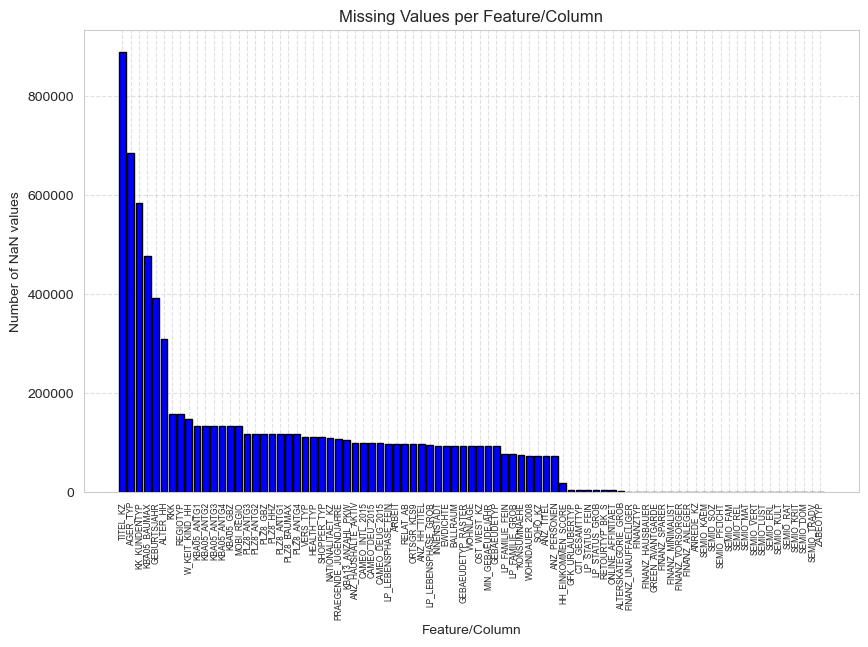

In [23]:
# Plot Histogram (Using a Bar Chart)
plt.figure(figsize=(10,6))
plt.bar(s_missing_per_feature.index, s_missing_per_feature.values, color="b", edgecolor='black')
plt.title('Missing Values per Feature/Column')
plt.xlabel('Feature/Column')
plt.xticks(rotation=90, ha="center", fontsize=6)
plt.ylabel('Number of NaN values')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Before we plot again, let us try to determine an appropiate threshold:

In [24]:
# Hard to visualize, convert to percentages
s_missing_per_feature_pct = (s_missing_per_feature / df_population.shape[0]) * 100

# Use pd.cut() to separate each column's percentage of missing values into defined ranges (bins)
bins = [0, 10, 20, 30, 40, 50,75, 100]
labels = ["0–10%", "10–20%", "20-30%", "30-40%", "40–50%",'50-75%', '75–100%']
s_missing_pct_bins = pd.cut(s_missing_per_feature_pct, bins=bins, labels=labels, include_lowest=True)

# Summarize by getting the count of each value and sorting
print(s_missing_pct_bins.value_counts().sort_index())

0–10%      39
10–20%     40
20-30%      0
30-40%      1
40–50%      1
50-75%      2
75–100%     2
Name: count, dtype: int64


As can be seen, a good threshold would be 20-30%, we choose 20%

We plot again, and add a visual for a threshold of 20%:

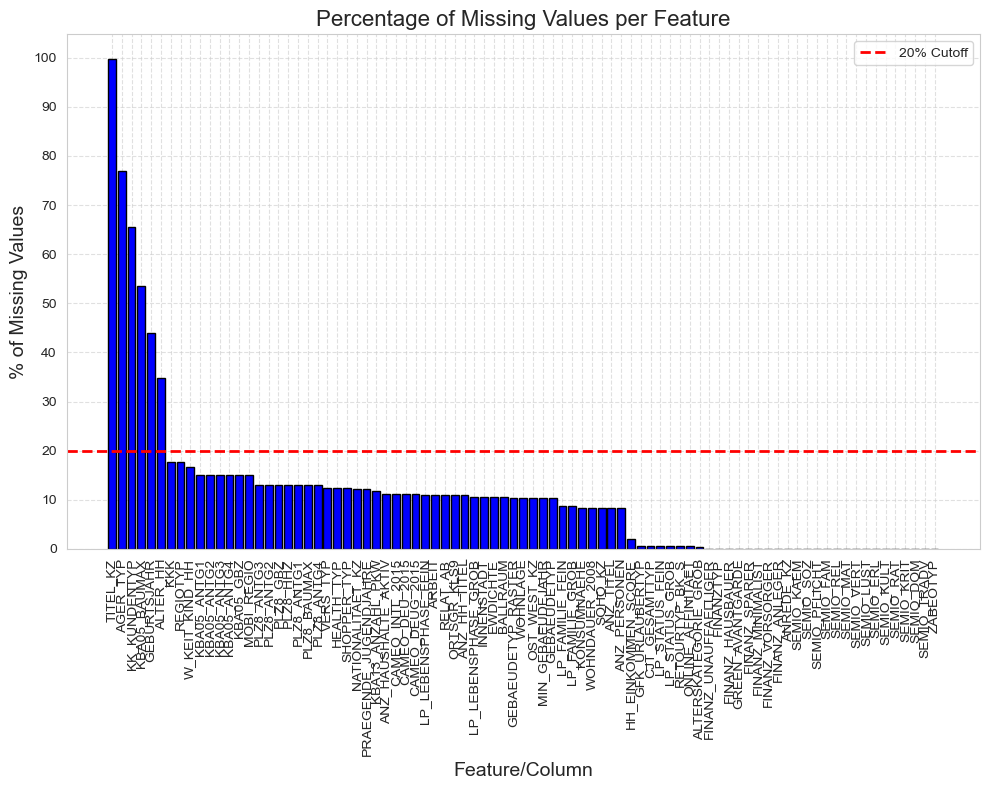

In [25]:
# Plot Percentages
plt.figure(figsize=(10,8))

plt.bar(s_missing_per_feature_pct.index, s_missing_per_feature_pct.values, color="b", edgecolor='black')

plt.title('Percentage of Missing Values per Feature', fontsize=16)
plt.xlabel('Feature/Column', fontsize=14)
plt.ylabel('% of Missing Values', fontsize=14)

plt.xticks(rotation=90, ha="center", fontsize=10)
plt.yticks(np.arange(0, 101, step=10))

# From the above
plt.axhline(y=20, color='r', linestyle='--', linewidth=2, label='20% Cutoff')
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

Now we proceed to remove the outlier columns from the dataset. We will use a custom transformer, so that we can reuse it, keep track of the features that are dropped along the course of the project and so that we can also include such transformer(s) in our future cleaning pipeline:

In [26]:
class FeatureDropper(BaseEstimator, TransformerMixin):
    """
    Custom transformer that drops features from a dataset.
    This class is designed so that a single feature dropper can be used
    to drop features at several places, keeping track of relevant information.
    More than one can also be used for different purposes.
    """

    def __init__(self):
        self.all_dropped_features = [] # keep track of all the features dropped by an instance
        self.last_dropped_features = [] # keep track of the last features that were dropped
        self.features_to_drop = [] # init list of the features to drop
        self.n_dropped_last = 0 # count of the last features dropped
        self.n_total_dropped = 0 # count of the total features drop

    def set_features_to_drop(self, features_to_drop):
        """
        Sets the features that will be dropped
        :param features_to_drop: features that will be dropped
        """
        self.features_to_drop = features_to_drop.copy()

    def check_features_set(self):
        """
        Checks that the features to drop list is valid
        :return:
        """
        if self.features_to_drop is None or len(self.features_to_drop) == 0:
            print(f"Features to drop not set. Please set by calling set_features_to_drop first.")
            print(f"No changes will be made to dataframe")
            return False
        return True

    def fit(self, X, y=None):

        # Keep track of the list of features coming in
        self.features_in_ = X.columns.to_list()
        return self

    def transform(self, X):

        # Check that we have set the features to drop
        self.check_features_set()
        X = X.copy()

        # Reset attributes
        self.last_dropped_features = []
        self.n_dropped_last = 0

        print(f"Dropping Features: {self.features_to_drop}")

        # Iterate over each feature set to be dropped
        for feature in self.features_to_drop:
            try:
                X.drop(feature, axis=1, inplace=True)
            except KeyError:
                print(f"{feature} not found in dataframe")
            else:
                # Update attributes
                self.all_dropped_features.append(feature)
                self.last_dropped_features.append(feature)
                self.n_dropped_last += 1
                self.n_total_dropped += 1

        # Clear the features to drop, for the next use
        self.features_to_drop.clear()
        print(f"Number of features dropped: {self.n_dropped_last}")
        return X

    def get_feature_names_out(self):
        """
        We need to set the get_feature_names_out when we use custom transformers
        So that we can get the correct feature/columns out after transformation
        :return:
        """

        # Return those features that came in that are not any that were dropped
        # In other words, the remaining features
        return [feature
                for feature in self.features_in_
                if feature not in self.last_dropped_features]

    def get_n_total_dropped(self):
        return self.n_total_dropped

    def get_n_last_dropped_features(self):
        return self.n_dropped_last

    def get_last_dropped_features(self):
        return self.last_dropped_features

    def get_all_dropped_features(self):
        return self.all_dropped_features

# Init the feature dropper that we will use throught the notebook
feature_dropper = FeatureDropper()

With our custom transfomer defined, we can proceed to drop the features/columns:

In [27]:
# Set threshold and get the list of features to drop
col_nan_threshold = 20
features_to_drop = list(s_missing_per_feature_pct[s_missing_per_feature_pct > col_nan_threshold].index)

# Set them in the feature_dropper and drop
feature_dropper.set_features_to_drop(features_to_drop)
df_population = feature_dropper.fit_transform(df_population)

# Update the dropped columns
feature_groups[TO_DROP][NA_FEATURES] = feature_dropper.get_last_dropped_features()

# Update the expected number of features
expected_n_features -= feature_dropper.get_n_last_dropped_features()

print(f"Dropped Features: {feature_dropper.get_last_dropped_features()}")
print(f"Expected Number of Features (rolling): {expected_n_features}")
df_population.head()

Dropping Features: ['TITEL_KZ', 'AGER_TYP', 'KK_KUNDENTYP', 'KBA05_BAUMAX', 'GEBURTSJAHR', 'ALTER_HH']
Number of features dropped: 6
Dropped Features: ['TITEL_KZ', 'AGER_TYP', 'KK_KUNDENTYP', 'KBA05_BAUMAX', 'GEBURTSJAHR', 'ALTER_HH']
Expected Number of Features (rolling): 79


,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,VERS_TYP,ZABEOTYP,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,2.0,1,2.0,3,4,3,5,5,3,4,10.0,0,NaN,15.0,4.0,2.0,2.0,1.0,1.0,NaN,NaN,5.0,2,6,7,5,1,5,3,3,4,7,6,6,5,3,NaN,NaN,NaN,3,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,2,5.0,1,5,2,5,4,5,1,10.0,0,3.0,21.0,6.0,5.0,3.0,2.0,1.0,1.0,14.0,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3.0,1.0,2.0,5,2.0,0.0,6.0,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
2,3.0,2,3.0,1,4,1,2,3,5,1,10.0,1,3.0,3.0,1.0,1.0,1.0,3.0,2.0,1.0,15.0,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2.0,0.0,1.0,5,1.0,0.0,4.0,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
3,4.0,2,2.0,4,2,5,2,1,2,6,1.0,0,2.0,NaN,NaN,NaN,NaN,9.0,4.0,1.0,8.0,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1.0,0.0,1.0,3,0.0,0.0,1.0,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2,2A,12,4.0,1.0,0.0,0.0,4.0,4.0,2.0,6.0,4.0,NaN,4.0,1.0,NaN,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
4,3.0,1,5.0,4,3,4,1,3,2,5,5.0,0,3.0,32.0,10.0,10.0,5.0,3.0,2.0,1.0,8.0,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2.0,0.0,2.0,4,4.0,0.0,5.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6,6B,43,1.0,4.0,1.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0


#### Discussion 1.1.2: Assess Missing Data in Each Column

As can be seen above from the graph and the summary of percentage missing values, the number of missing values is not uniformly distributed across the dataset. 39/85 columns are missing 0-10% and 40/85 columns are missing 10-20% of values. This can be remedied later with imputation. I decided to use 20% missing values as a threshold based on the information gathered.

The columns dropped are:
- **'AGER_TYP'**: Best-ager typology. >70% missing data.
- **'GEBURTSJAHR'**: Year of birth. >40% missing data.
- **'TITEL_KZ'**: Academic title flag. >99% missing data.
- **'ALTER_HH'**: Birthdate of head of household. >30% missing data.
- **'KK_KUNDENTYP'**: Consumer pattern over past 12 months. >65% missing data.
- **'KBA05_BAUMAX'**: Most common building type within microcell. >50% missing data.

#### Step 1.1.3: Assess Missing Data in Each Row

Now, you'll perform a similar assessment for the rows of the dataset. How much data is missing in each row? As with the columns, you should see some groups of points that have a very different numbers of missing values. Divide the data into two subsets: one for data points that are above some threshold for missing values, and a second subset for points below that threshold.

In order to know what to do with the outlier rows, we should see if the distribution of data values on columns that are not missing data (or are missing very little data) are similar or different between the two groups. Select at least five of these columns and compare the distribution of values.
- You can use seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) function to create a bar chart of code frequencies and matplotlib's [`subplot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.subplot.html) function to put bar charts for the two subplots side by side.
- To reduce repeated code, you might want to write a function that can perform this comparison, taking as one of its arguments a column to be compared.

Depending on what you observe in your comparison, this will have implications on how you approach your conclusions later in the analysis. If the distributions of non-missing features look similar between the data with many missing values and the data with few or no missing values, then we could argue that simply dropping those points from the analysis won't present a major issue. On the other hand, if the data with many missing values looks very different from the data with few or no missing values, then we should make a note on those data as special. We'll revisit these data later on. **Either way, you should continue your analysis for now using just the subset of the data with few or no missing values.**

In [28]:
# How much data is missing in each row of the dataset?
def get_na_per_row(df):
    # How much data is missing in each row of the dataset?
    # Get the sum of NaN values per row
    na_p_row = df.isna().sum(axis=1)
    na_p_row.sort_values(ascending=False, inplace=True)
    return na_p_row

s_na_per_row = get_na_per_row(df_population)

print(s_na_per_row.describe())
s_na_per_row.head(10)

count    891221.000000
mean          5.649894
std          13.234687
min           0.000000
25%           0.000000
50%           0.000000
75%           3.000000
max          49.000000
dtype: float64


732775    49
643174    49
472919    48
345274    47
299868    47
582092    47
681255    47
818343    47
582109    47
439981    47
dtype: int64

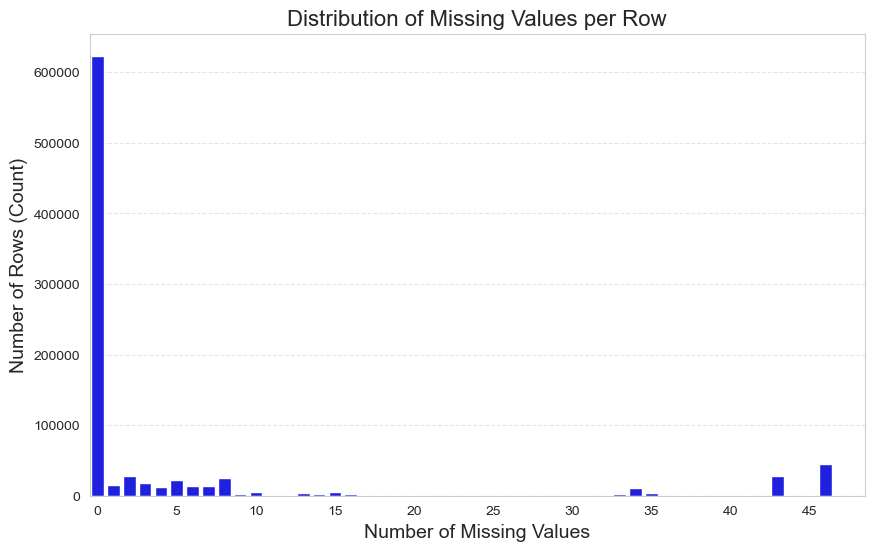

In [29]:
# Plot the frequencies
plt.figure(figsize=(10, 6))

sns.countplot(x=s_na_per_row, color='b')

plt.title('Distribution of Missing Values per Row', fontsize=16)
plt.xlabel('Number of Missing Values', fontsize=14)
plt.ylabel('Number of Rows (Count)', fontsize=14)

plt.xticks(ticks=range(0, max(s_na_per_row) + 1, 5),
           labels=range(0, max(s_na_per_row) + 1, 5),
           rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

As can be seen by the histogram, most of the rows are complete, with a small spike of rows missing. Looking at the distribution plot, we can split at around 25 missing values.

Now we can write the transformer to do this. We will use a custom transformer so we can integrate it into our cleaning pipeline.

In [30]:
# Write code to divide the data into two subsets based on the number of missing
# values in each row.

# Create Our Dataset Splitter
class DatasetSplitter(BaseEstimator, TransformerMixin):
    """
    Custom Transformer that splits a dataset by threshold of the count of NaN values per row.
    This might not be the most correct way to do it, following sklearn conventions, because
    eventually we are returning 2 different subsets of the data but it works for this project.
    """

    def __init__(self, threshold):
        self.threshold = threshold

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()

        # Get counts of missings per row
        missing_per_row = X.isna().sum(axis=1)


        # Split the dataset into two, based on the threshold
        # Technically learned attributes should be set in fit()
        # But I do it here since I consider it transforming the data
        self.high_na_df_ = X[missing_per_row > self.threshold]
        self.low_na_df_ = X[missing_per_row <= self.threshold]

        # We can reset index here rather than later
        self.high_na_df_.reset_index(drop=True, inplace=True)
        self.low_na_df_.reset_index(drop=True, inplace=True)

        # Keep track of the number of rows dropped
        self.n_dropped_rows_ = self.high_na_df_.shape[0]

        return self.low_na_df_

    def set_output(self, *, transform=None):
        return self

    def get_high_missing_subset(self):
        # Since a transformer can only return one dataset,
        # we use a separate function to return the high missings
        # subset
        return self.high_na_df_

    def get_n_rows_dropped(self):
        return self.n_dropped_rows_

# Init the splitter we will use
splitter = DatasetSplitter(threshold=25)

With our custom data splitter, we can proceed to split the population data into two subsets:

In [31]:
# Now we split the dataset into two
df_pop_low_missing = splitter.fit_transform(df_population)
df_pop_high_missing = splitter.get_high_missing_subset()

dropped_row_count = splitter.get_n_rows_dropped()

print(f"Number of rows dropped: {dropped_row_count}")
print(f"Total # of rows after dropping columns: {df_population.shape[0]}")
print(f"Total # of missing values in rows: {s_na_per_row.sum().item()}")
print(f"Total # of rows in low missing subset: {df_pop_low_missing.shape[0]}")
print(f"Total # of missing values in rows of low missing subset: {df_pop_low_missing.isna().sum().sum()}")

Number of rows dropped: 93260
Total # of rows after dropping columns: 891221
Total # of missing values in rows: 5035304
Total # of rows in low missing subset: 797961
Total # of missing values in rows of low missing subset: 1011517


In [32]:
# Display info
df_pop_low_missing.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797961 entries, 0 to 797960
Columns: 79 entries, ALTERSKATEGORIE_GROB to RELAT_AB
dtypes: float64(51), int64(24), object(4)
memory usage: 480.9+ MB


In [33]:
# Explore the relevant data (low missings)
df_pop_low_missing.head()

,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,VERS_TYP,ZABEOTYP,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,1.0,2,5.0,1,5,2,5,4,5,1,10.0,0,3.0,21.0,6.0,5.0,3.0,2.0,1.0,1.0,14.0,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3.0,1.0,2.0,5,2.0,0.0,6.0,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8,8A,51,0.0,0.0,0.0,2.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
1,3.0,2,3.0,1,4,1,2,3,5,1,10.0,1,3.0,3.0,1.0,1.0,1.0,3.0,2.0,1.0,15.0,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2.0,0.0,1.0,5,1.0,0.0,4.0,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4,4C,24,1.0,3.0,1.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
2,4.0,2,2.0,4,2,5,2,1,2,6,1.0,0,2.0,NaN,NaN,NaN,NaN,9.0,4.0,1.0,8.0,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1.0,0.0,1.0,3,0.0,0.0,1.0,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2,2A,12,4.0,1.0,0.0,0.0,4.0,4.0,2.0,6.0,4.0,NaN,4.0,1.0,NaN,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
3,3.0,1,5.0,4,3,4,1,3,2,5,5.0,0,3.0,32.0,10.0,10.0,5.0,3.0,2.0,1.0,8.0,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2.0,0.0,2.0,4,4.0,0.0,5.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6,6B,43,1.0,4.0,1.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0
4,1.0,2,2.0,3,1,5,2,2,5,2,1.0,0,3.0,8.0,2.0,1.0,1.0,4.0,2.0,1.0,3.0,3.0,2,4,7,4,2,2,2,5,7,4,4,4,7,6,0.0,0.0,2.0,4,1.0,0.0,5.0,6.0,9.0,5.0,0.0,1.0,5.0,1992.0,W,7.0,8,8C,54,2.0,2.0,0.0,0.0,4.0,6.0,2.0,7.0,4.0,4.0,4.0,1.0,5.0,1300.0,2.0,3.0,1.0,1.0,1.0,5.0,5.0,2.0,3.0,3.0


We have therefore decreased the number of rows from 891,221 to 797,961 (\~10% decrease) and the total number of missing values from 5,035,304 to 1,011,517 (\~80% decrease).

#### Comparing Distribution of Values Between Accepted and Rejected Subsets

In [34]:
# Let's recall the missing_per_feature_pct data frame
s_missing_per_feature_pct.head()

TITEL_KZ        99.757636
AGER_TYP        76.955435
KK_KUNDENTYP    65.596749
KBA05_BAUMAX    53.468668
GEBURTSJAHR     44.020282
dtype: float64

In [35]:
# Select 5 features/columns that have 0 missing values

# First we get all columns with 0 missing values
zero_missing_cols = s_missing_per_feature_pct[s_missing_per_feature_pct == 0].index.to_list()

# Then we choose 5 random ones
comparison_cols = random.choices(zero_missing_cols, k=5)
print(f"Columns/Features that will be compared: {comparison_cols}")

Columns/Features that will be compared: ['SEMIO_VERT', 'FINANZ_UNAUFFAELLIGER', 'FINANZ_VORSORGER', 'FINANZ_MINIMALIST', 'SEMIO_ERL']


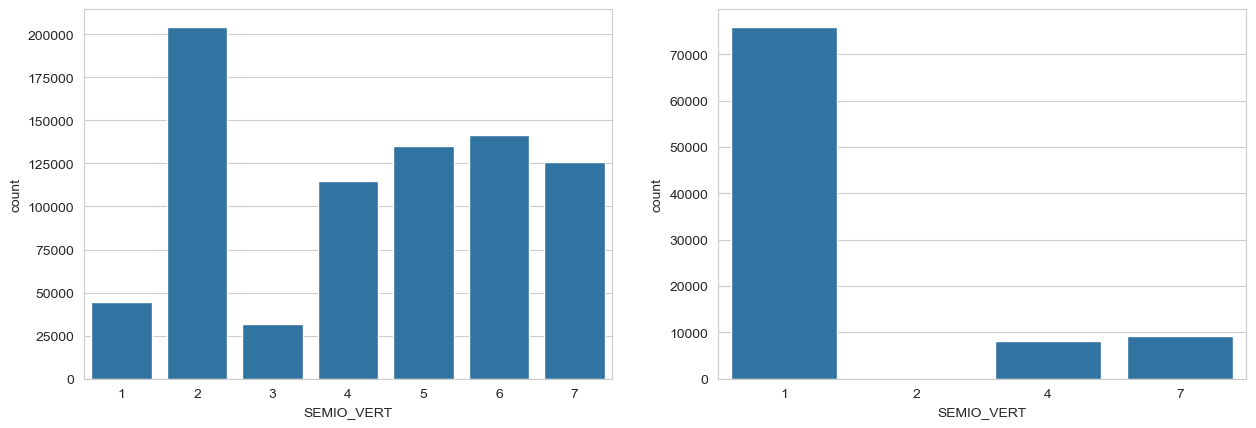

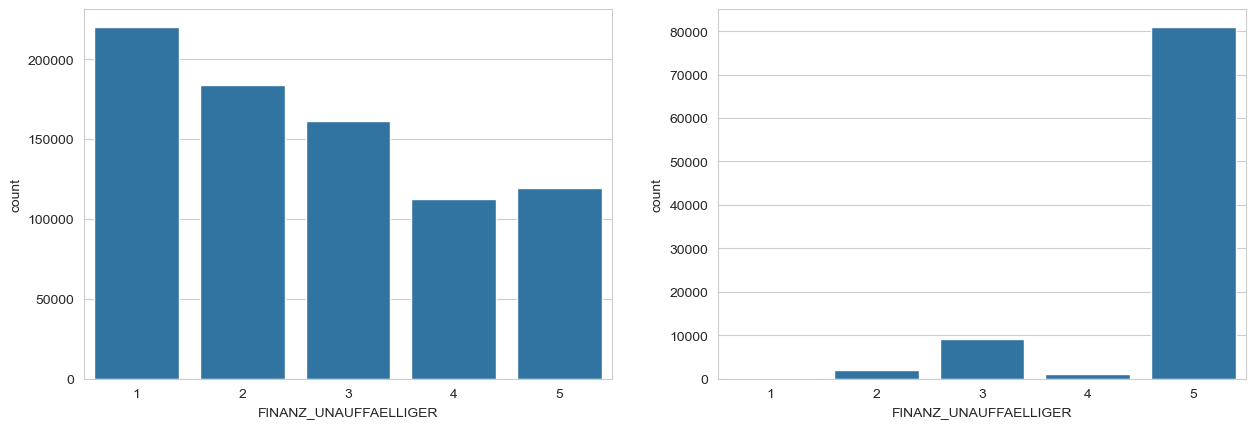

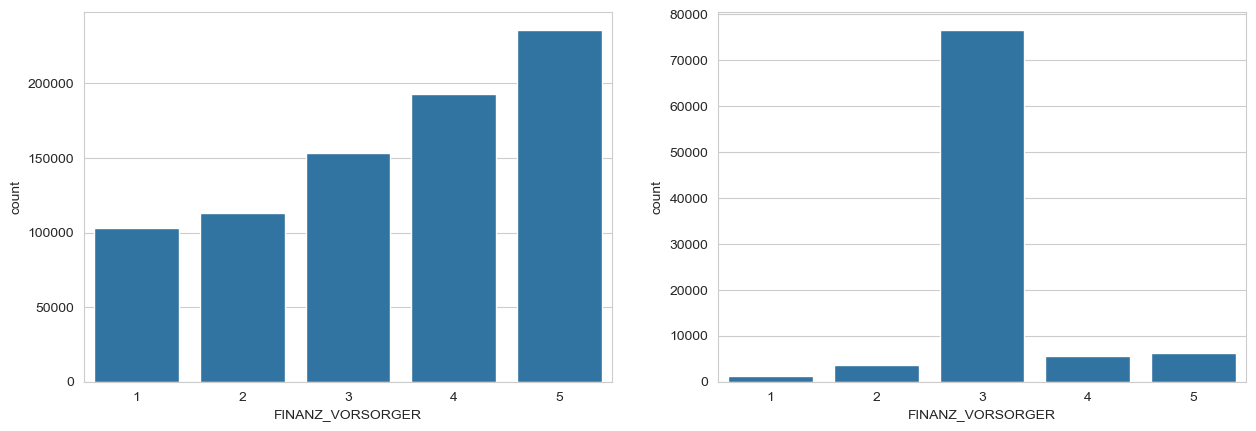

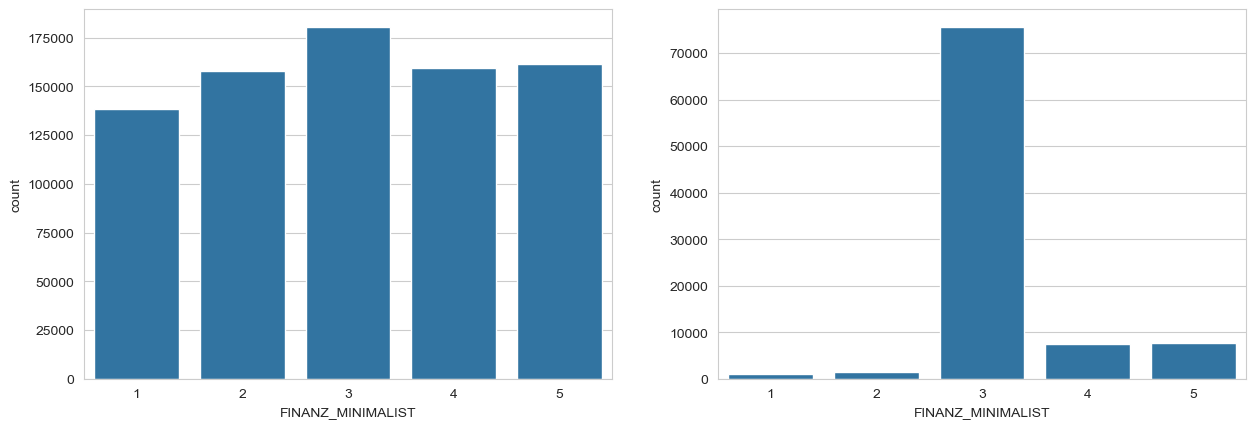

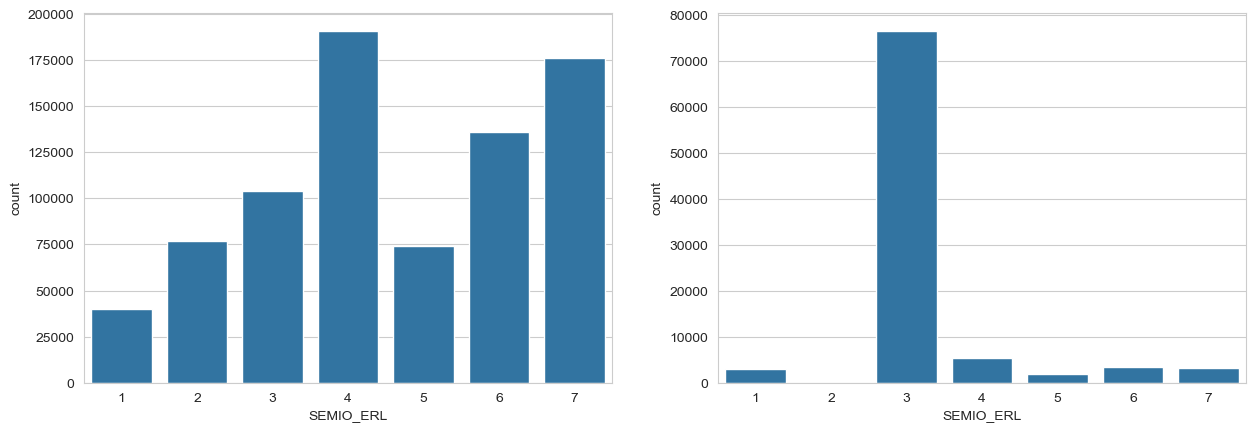

In [36]:
# Compare the distribution of values for at least five columns where there are
# no or few missing values, between the two subsets.
def plot_subset_missing_dist(col_label):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_figwidth(15)

    sns.countplot(x=col_label, data=df_pop_low_missing, ax=ax1)
    sns.countplot(x=col_label, data=df_pop_high_missing, ax=ax2)

    plt.show()

for c in comparison_cols:
    plot_subset_missing_dist(c)

#### Discussion 1.1.3: Assess Missing Data in Each Row

As seen in the cells above, for na_per_row, the mean is ~5.64, so ~6 values are missing per row on average, which I would say is rather acceptable. 50% of the data has complete rows, and 75% is missing only 3 values. STD is 13.23, which is rather high. What we observe then is that there are rows that have many missing values (up to 49 max), which are simply unreliable and should be dropped (or not used, as per our subset data).

Comparison of the plots shows that the distributions between accepted and rejected are different, so we cannot simply drop those rows. However, despite the fact that we cannot drop the rows, we can notice on the rejected subset that some features have biased distributions since we can see bars on the chart that are dominated by a single value/category.

In [37]:
# Before we move on, let's clear up memory
del df_population
del s_col_missing_counts
del s_missing_per_feature
del s_missing_per_feature_pct
del s_missing_pct_bins
del s_na_per_row

gc.collect()

48459

### Step 1.2: Select and Re-Encode Features

Checking for missing data isn't the only way in which you can prepare a dataset for analysis. Since the unsupervised learning techniques to be used will only work on data that is encoded numerically, you need to make a few encoding changes or additional assumptions to be able to make progress. In addition, while almost all of the values in the dataset are encoded using numbers, not all of them represent numeric values. Check the third column of the feature summary (`feat_info`) for a summary of types of measurement.
- For numeric and interval data, these features can be kept without changes.
- Most of the variables in the dataset are ordinal in nature. While ordinal values may technically be non-linear in spacing, make the simplifying assumption that the ordinal variables can be treated as being interval in nature (that is, kept without any changes).
- Special handling may be necessary for the remaining two variable types: categorical, and 'mixed'.

In the first two parts of this sub-step, you will perform an investigation of the categorical and mixed-type features and make a decision on each of them, whether you will keep, drop, or re-encode each. Then, in the last part, you will create a new data frame with only the selected and engineered columns.

Data wrangling is often the trickiest part of the data analysis process, and there's a lot of it to be done here. But stick with it: once you're done with this step, you'll be ready to get to the machine learning parts of the project!

In [38]:
# How many features are there of each data type?

# get a list of features in our pop_low_missing data
feature_list = df_pop_low_missing.columns.to_list()

# Index only those attributes that are in our pop_low_missing
feature_summary[feature_summary[FS_ATTR].isin(feature_list)][FS_TYPE].value_counts()

type
ordinal        49
categorical    18
mixed           6
numeric         6
Name: count, dtype: int64

#### Step 1.2.1: Re-Encode Categorical Features

For categorical data, you would ordinarily need to encode the levels as dummy variables. Depending on the number of categories, perform one of the following:
- For binary (two-level) categoricals that take numeric values, you can keep them without needing to do anything.
- There is one binary variable that takes on non-numeric values. For this one, you need to re-encode the values as numbers or create a dummy variable.
- For multi-level categoricals (three or more values), you can choose to encode the values using multiple dummy variables (e.g. via [OneHotEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)), or (to keep things straightforward) just drop them from the analysis. As always, document your choices in the Discussion section.

First, let's look at all the categorical features:

In [39]:
# Get a list of all the categorical features
categorical_feats = list(feature_summary[
                     (feature_summary[FS_ATTR].isin(feature_list)) &
                     (feature_summary[FS_TYPE] == CATEGORICAL)][FS_ATTR])

for f in categorical_feats:
    print(f)
    pprint(feature_dictionary[f], compact=True)
    print(f"Unique Values: {df_pop_low_missing[f].nunique()} (not including NaNs)")
    print()

ANREDE_KZ
{'codes': {'-1': 'unknown (missing)',
           '0': 'unknown (cannot be determined)',
           '1': 'male',
           '2': 'female'},
 'desc': 'Gender'}
Unique Values: 2 (not including NaNs)

CJT_GESAMTTYP
{'codes': {'0': 'unknown',
           '1': 'Advertising- and Consumptionminimalist',
           '2': 'Advertising- and Consumptiontraditionalist',
           '3': 'advertisinginterested Store-shopper',
           '4': 'advertisinginterested Online-shopper',
           '5': 'Advertising- and Cross-Channel-Enthusiast',
           '6': 'Advertising-Enthusiast with restricted '
                'Cross-Channel-Behaviour'},
 'desc': 'Customer-Journey-Typology: preferred information and buying channels '
         'for consumer'}
Unique Values: 6 (not including NaNs)

FINANZTYP
{'codes': {'-1': 'unknown',
           '1': 'low financial interest (MINIMALIST)',
           '2': 'money-saver (SPARER)',
           '3': 'home ownership (HAUSBAUER)',
           '4': 'be prepared (VORS

#### Summary of Categorical Features:

- **ANREDE_KZ**: Gender. Could be useful. Keep.
- **CJT_GESAMTTYP**: Customer-Journey-Typology: preferred information and buying channels for consumer. Keep.
- **FINANZTYP**: Most descriptive financial type for individual. Keep.
- **GFK_URLAUBERTYP**: Vacation habits. Could be relevant. Keep.
- **GREEN_AVANTGARDE**: Membership in environmental sustainability as part of youth. Could be relevant for environmentally concious consumers. Keep.
- **LP_FAMILIE_FEIN**: Family type, fine scale. Keep.
- **LP_FAMILIE_GROB**: Family type, rough scale. **Drop,** using the fine scale.
- **LP_STATUS_FEIN**: Social status, fine scale. Keep.
- **LP_STATUS_GROB**: Social status, rough scale. **Drop,** using the fine scale.
- **NATIONALITAET_KZ**: Nationality based on given name analysis. Very broad and few categories. **Drop.**
- **SHOPPER_TYP**: Shopper typology. Relevant. Keep.
- **SOHO_KZ**: Small office / home office flag. Don't think it is too relevant. I think the other features can capture better information. **Drop.**
- **VERS_TYP**: Insurance typology, related to risk. Could be relevant. Keep.
- **ZABEOTYP**: Energy consumption typology. Could be relevant. Keep.
- **KK_KUNDENTYP**: Consumer pattern over past 12 months. Keep.
- **GEBAEUDETYP**: Type of building (residential vs. commercial). Keep.
- **OST_WEST_KZ**: Building location via former East / West Germany. I don't know if former East/West Germany can influence consumer behavior. Keep.
- **CAMEO_DEUG_2015**: German CAMEO: Wealth / Life Stage Typology, rough scale. Will use fine scale. **Drop.**
- **CAMEO_DEU_2015**: German CAMEO: Wealth / Life Stage Typology, detailed scale. Many categories which can lead to "dimensionality course". Keep.

In [40]:
# Add the features we will drop, based on our choices above
def extend_no_duplicates(original_list, new_items):
    """
    Helper function to ensure we are not adding duplicates to our lists (happens a lot)
    :param original_list: the original list to append new items to
    :param new_items: the new items to append
    """

    # make sure no duplicates in new_items
    new_items = list(set(new_items))

    for item in new_items:
        if item not in original_list:
            original_list.append(item)

extend_no_duplicates(feature_groups[TO_DROP][CATEGORICAL], ["LP_FAMILIE_GROB", "LP_STATUS_GROB", "NATIONALITAET_KZ", "SOHO_KZ", "CAMEO_DEUG_2015"])

print(feature_groups[TO_DROP][CATEGORICAL])

['LP_FAMILIE_GROB', 'CAMEO_DEUG_2015', 'LP_STATUS_GROB', 'SOHO_KZ', 'NATIONALITAET_KZ']


Now we drop these 5 features:

In [41]:
# we reuse the feature_dropper (convenient!)
# set the features to drop and fit_transform()
feature_dropper.set_features_to_drop(feature_groups[TO_DROP][CATEGORICAL])
df_pop_low_missing = feature_dropper.fit_transform(df_pop_low_missing)
df_pop_low_missing.head()

Dropping Features: ['LP_FAMILIE_GROB', 'CAMEO_DEUG_2015', 'LP_STATUS_GROB', 'SOHO_KZ', 'NATIONALITAET_KZ']
Number of features dropped: 5


,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_STATUS_FEIN,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,VERS_TYP,ZABEOTYP,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,1.0,2,5.0,1,5,2,5,4,5,1,10.0,0,3.0,21.0,6.0,5.0,2.0,14.0,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3.0,2.0,5,2.0,0.0,6.0,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,W,4.0,8A,51,0.0,0.0,0.0,2.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
1,3.0,2,3.0,1,4,1,2,3,5,1,10.0,1,3.0,3.0,1.0,1.0,3.0,15.0,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2.0,1.0,5,1.0,0.0,4.0,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,W,2.0,4C,24,1.0,3.0,1.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
2,4.0,2,2.0,4,2,5,2,1,2,6,1.0,0,2.0,NaN,NaN,NaN,9.0,8.0,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1.0,1.0,3,0.0,0.0,1.0,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,W,7.0,2A,12,4.0,1.0,0.0,0.0,4.0,4.0,2.0,6.0,4.0,NaN,4.0,1.0,NaN,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
3,3.0,1,5.0,4,3,4,1,3,2,5,5.0,0,3.0,32.0,10.0,10.0,3.0,8.0,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2.0,2.0,4,4.0,0.0,5.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,W,3.0,6B,43,1.0,4.0,1.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0
4,1.0,2,2.0,3,1,5,2,2,5,2,1.0,0,3.0,8.0,2.0,1.0,4.0,3.0,3.0,2,4,7,4,2,2,2,5,7,4,4,4,7,6,0.0,2.0,4,1.0,0.0,5.0,6.0,9.0,5.0,0.0,1.0,5.0,1992.0,W,7.0,8C,54,2.0,2.0,0.0,0.0,4.0,6.0,2.0,7.0,4.0,4.0,4.0,1.0,5.0,1300.0,2.0,3.0,1.0,1.0,1.0,5.0,5.0,2.0,3.0,3.0


In [42]:
# Update the expected number of features
expected_n_features -= feature_dropper.get_n_last_dropped_features()
expected_n_features

74

Now that we have dropped the categorical features we do not want, we can asses the remaining categorical features:

In [43]:
# Assess categorical variables: which are binary, which are multi-level, and
# which one needs to be re-encoded?
def get_categorical_features(df, fs, fg):
    """
    Function that sets binary, multi-level, and non-numeric categorical features
    in the feature groups dictionary
    :param df: The target DataFrame
    :param fs: The feature summary for the DataFrame
    :param fg: The feature group dictionary to update
    """

    # get a list of all features
    f_list = df.columns.to_list()

    # get a list of all categorical features
    c_features = list(fs[
                            (fs[FS_ATTR].isin(f_list)) &
                            (fs[FS_TYPE] == CATEGORICAL)
                        ][FS_ATTR])

    # iterate over each categorical
    for feat in c_features:

        # skip over the dropped categorical features
        if feat in fg[TO_DROP][CATEGORICAL]:
            # continue and do not append to any list
            continue

        # check for binary ones
        if df[feat].nunique() == 2:
            # check if numeric or not
            if df[feat].dtype == FS_OBJ:
                if feat not in fg[BIN_NO_NUM]:
                    fg[BIN_NO_NUM].append(feat)
            else:
                if feat not in fg[BINARY]:
                    fg[BINARY].append(feat)
        # else, it is a multi-level categorical
        else:
            if feat not in fg[MULTI]:
                fg[MULTI].append(feat)

get_categorical_features(df_pop_low_missing, feature_summary, feature_groups)

print(f"=========================================================")
print(f"========== ASSESSMENT OF CATEGORICAL FEATURES: ==========")
print(f"=========================================================\n")
print(f"Binary: {feature_groups[BINARY]}\n")
print(f"Multi-level: {feature_groups[MULTI]}\n")
print(f"Non-numeric (to re-encode): {feature_groups[BIN_NO_NUM]}")

========== ASSESSMENT OF CATEGORICAL FEATURES: ==========

Binary: ['ANREDE_KZ', 'GREEN_AVANTGARDE', 'VERS_TYP']

Multi-level: ['CJT_GESAMTTYP', 'FINANZTYP', 'GFK_URLAUBERTYP', 'LP_FAMILIE_FEIN', 'LP_STATUS_FEIN', 'SHOPPER_TYP', 'ZABEOTYP', 'GEBAEUDETYP', 'CAMEO_DEU_2015']

Non-numeric (to re-encode): ['OST_WEST_KZ']


As per the instructions, we will keep the binary categorical features as is, encode the multi-level categorical features and re-encode 'OST_WEST_KZ'.

#### Re-encode 'OST_WEST_KZ':

In [44]:
# Explore 'OST_WEST_KZ':
print(df_pop_low_missing[OST_WEST].value_counts())
df_pop_low_missing[OST_WEST].head()

OST_WEST_KZ
W    629433
O    168528
Name: count, dtype: int64


0    W
1    W
2    W
3    W
4    W
Name: OST_WEST_KZ, dtype: object

To re-encode, we just re-encode the values as numbers. We use an OrdinalEncoder.

In [45]:
# Create the ordinal encoder and ColumnTransformer to easily select the columns to encode
ordinal_encoder = OrdinalEncoder(categories=[['O', 'W']], encoded_missing_value=np.nan)

ost_west_kz_encoder = ColumnTransformer([
    ('ordinal', ordinal_encoder, [OST_WEST])
], remainder='passthrough', verbose_feature_names_out=False).set_output(transform="pandas")

In [46]:
# Re-encode categorical variable(s) to be kept
df_pop_low_missing = ost_west_kz_encoder.fit_transform(df_pop_low_missing)
df_pop_low_missing.head()

,OST_WEST_KZ,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_STATUS_FEIN,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,VERS_TYP,ZABEOTYP,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,WOHNLAGE,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,1.0,1.0,2,5.0,1,5,2,5,4,5,1,10.0,0,3.0,21.0,6.0,5.0,2.0,14.0,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,3.0,2.0,5,2.0,0.0,6.0,3.0,9.0,11.0,0.0,8.0,1.0,1992.0,4.0,8A,51,0.0,0.0,0.0,2.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
1,1.0,3.0,2,3.0,1,4,1,2,3,5,1,10.0,1,3.0,3.0,1.0,1.0,3.0,15.0,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,2.0,1.0,5,1.0,0.0,4.0,3.0,9.0,10.0,0.0,1.0,5.0,1992.0,2.0,4C,24,1.0,3.0,1.0,0.0,3.0,2.0,4.0,4.0,4.0,2.0,3.0,2.0,2.0,712.0,3.0,3.0,1.0,0.0,1.0,4.0,4.0,3.0,5.0,2.0
2,1.0,4.0,2,2.0,4,2,5,2,1,2,6,1.0,0,2.0,NaN,NaN,NaN,9.0,8.0,2.0,5,1,2,1,4,4,7,4,3,4,4,5,4,4,1.0,1.0,3,0.0,0.0,1.0,NaN,9.0,1.0,0.0,1.0,4.0,1997.0,7.0,2A,12,4.0,1.0,0.0,0.0,4.0,4.0,2.0,6.0,4.0,NaN,4.0,1.0,NaN,596.0,2.0,2.0,2.0,0.0,1.0,3.0,4.0,2.0,3.0,3.0
3,1.0,3.0,1,5.0,4,3,4,1,3,2,5,5.0,0,3.0,32.0,10.0,10.0,3.0,8.0,5.0,6,4,4,2,7,4,4,6,2,3,2,2,4,2,2.0,2.0,4,4.0,0.0,5.0,2.0,9.0,3.0,0.0,1.0,4.0,1992.0,3.0,6B,43,1.0,4.0,1.0,0.0,3.0,2.0,5.0,1.0,5.0,3.0,3.0,5.0,5.0,435.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,4.0,6.0,5.0
4,1.0,1.0,2,2.0,3,1,5,2,2,5,2,1.0,0,3.0,8.0,2.0,1.0,4.0,3.0,3.0,2,4,7,4,2,2,2,5,7,4,4,4,7,6,0.0,2.0,4,1.0,0.0,5.0,6.0,9.0,5.0,0.0,1.0,5.0,1992.0,7.0,8C,54,2.0,2.0,0.0,0.0,4.0,6.0,2.0,7.0,4.0,4.0,4.0,1.0,5.0,1300.0,2.0,3.0,1.0,1.0,1.0,5.0,5.0,2.0,3.0,3.0


In [47]:
# Check values
print(df_pop_low_missing[OST_WEST].value_counts())

OST_WEST_KZ
1.0    629433
0.0    168528
Name: count, dtype: int64


The counts match as per the values before encoding. We have successfully encoded 'OST_WEST_KZ".

#### Encode Multi-Level Categoricals:

To encode the remaining multi-level categoricals, we will use OneHotEncode inside a ColumnTransformer. That way we prevent making mistakes like not setting the correct feature names, or mixing up the data, as could happen if we did it all manually (this happened a lot during my testing):

In [48]:
# Take a peek at the multi-level categoricals
df_pop_low_missing[feature_groups[MULTI]].head()

,CJT_GESAMTTYP,FINANZTYP,GFK_URLAUBERTYP,LP_FAMILIE_FEIN,LP_STATUS_FEIN,SHOPPER_TYP,ZABEOTYP,GEBAEUDETYP,CAMEO_DEU_2015
0,5.0,1,10.0,5.0,2.0,3.0,5,8.0,8A
1,3.0,1,10.0,1.0,3.0,2.0,5,1.0,4C
2,2.0,6,1.0,NaN,9.0,1.0,3,1.0,2A
3,5.0,5,5.0,10.0,3.0,2.0,4,1.0,6B
4,2.0,2,1.0,1.0,4.0,0.0,4,1.0,8C


In [49]:
# Create a dataframe of the multicategoricals and if they have a NaN value
df_multi_has_na = pd.DataFrame({
    'has_nan': df_pop_low_missing[feature_groups[MULTI]].isna().any()
})

# Create a dataframe of the unique values, rename the single column to 'n_unique'
df_multi_nunique = df_pop_low_missing[feature_groups[MULTI]].nunique().rename('n_unique')

# Concatenate both to create a single dataframe
df_multi_info = pd.concat([df_multi_nunique, df_multi_has_na], axis=1)
df_multi_info

,n_unique,has_nan
CJT_GESAMTTYP,6,True
FINANZTYP,6,False
GFK_URLAUBERTYP,12,True
LP_FAMILIE_FEIN,11,True
LP_STATUS_FEIN,10,True
SHOPPER_TYP,4,True
ZABEOTYP,6,False
GEBAEUDETYP,7,False
CAMEO_DEU_2015,44,True


In [50]:
# Free memory
del df_multi_has_na, df_multi_nunique, df_multi_info

gc.collect()

21383

In [51]:
# Create the OneHotEncoder, we use handle_unknown='ignore' to handle missing values
# and sparse_ouput=False, because Pandas does not support sparse_output
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

categorical_encoder = ColumnTransformer(
    transformers=[
        ('categorical', one_hot_encoder, feature_groups[MULTI]),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform="pandas")

Based on the columns, unique types, etc., we should get the following after encoding the 8 feature columns:
- **CJT_GESAMTTYP**: We should get 6 new columns + 1 NaN column = 7 new columns
- **FINANZTYP**: We should get 6 new columns
- **GFK_URLAUBERTYP**: We should get 12 new columns + 1 NaN column = 13 new columns
- **LP_FAMILIE_FEIN**: We should get 11 new columns + 1 NaN column = 12 new columns
- **LP_STATUS_FEIN**: We should get 10 new columns + 1 NaN column = 11 new columns
- **SHOPPER_TYP**: We should get 4 new columns + 1 NaN column = 5 new columns
- **ZABEOTYP**: We should get 6 new columns
- **GEBAEUDETYP**: We should get 7 new columns
- **CAMEO_DEU_2015**: We should get 44 new columns + 1 NaN column = 45 new columns

In total, this adds up to 112 new columns

In [52]:
# Use the encoder
df_pop_encoded = categorical_encoder.fit_transform(df_pop_low_missing)

# Update feature groups, getting the features out from one hot encoding
# To get the specific encoder, we access it from the .named_transformers_ attribute of the
# ColumnTransformer
one_hot_encoded_features = categorical_encoder.named_transformers_['categorical'].get_feature_names_out()
extend_no_duplicates(feature_groups[ENCODED_FEATURES], one_hot_encoded_features)

# Visualize results
df_pop_encoded[one_hot_encoded_features].head()

,CJT_GESAMTTYP_1.0,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,CJT_GESAMTTYP_nan,FINANZTYP_1,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,GFK_URLAUBERTYP_1.0,GFK_URLAUBERTYP_2.0,GFK_URLAUBERTYP_3.0,GFK_URLAUBERTYP_4.0,GFK_URLAUBERTYP_5.0,GFK_URLAUBERTYP_6.0,GFK_URLAUBERTYP_7.0,GFK_URLAUBERTYP_8.0,GFK_URLAUBERTYP_9.0,GFK_URLAUBERTYP_10.0,GFK_URLAUBERTYP_11.0,GFK_URLAUBERTYP_12.0,GFK_URLAUBERTYP_nan,LP_FAMILIE_FEIN_1.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_nan,LP_STATUS_FEIN_1.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_nan,SHOPPER_TYP_0.0,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SHOPPER_TYP_nan,ZABEOTYP_1,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6,GEBAEUDETYP_1.0,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,CAMEO_DEU_2015_1A,CAMEO_DEU_2015_1B,CAMEO_DEU_2015_1C,CAMEO_DEU_2015_1D,CAMEO_DEU_2015_1E,CAMEO_DEU_2015_2A,CAMEO_DEU_2015_2B,CAMEO_DEU_2015_2C,CAMEO_DEU_2015_2D,CAMEO_DEU_2015_3A,CAMEO_DEU_2015_3B,CAMEO_DEU_2015_3C,CAMEO_DEU_2015_3D,CAMEO_DEU_2015_4A,CAMEO_DEU_2015_4B,CAMEO_DEU_2015_4C,CAMEO_DEU_2015_4D,CAMEO_DEU_2015_4E,CAMEO_DEU_2015_5A,CAMEO_DEU_2015_5B,CAMEO_DEU_2015_5C,CAMEO_DEU_2015_5D,CAMEO_DEU_2015_5E,CAMEO_DEU_2015_5F,CAMEO_DEU_2015_6A,CAMEO_DEU_2015_6B,CAMEO_DEU_2015_6C,CAMEO_DEU_2015_6D,CAMEO_DEU_2015_6E,CAMEO_DEU_2015_6F,CAMEO_DEU_2015_7A,CAMEO_DEU_2015_7B,CAMEO_DEU_2015_7C,CAMEO_DEU_2015_7D,CAMEO_DEU_2015_7E,CAMEO_DEU_2015_8A,CAMEO_DEU_2015_8B,CAMEO_DEU_2015_8C,CAMEO_DEU_2015_8D,CAMEO_DEU_2015_9A,CAMEO_DEU_2015_9B,CAMEO_DEU_2015_9C,CAMEO_DEU_2015_9D,CAMEO_DEU_2015_9E,CAMEO_DEU_2015_nan
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0

In [53]:
# Check the full data
df_pop_encoded.head()

,CJT_GESAMTTYP_1.0,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,CJT_GESAMTTYP_nan,FINANZTYP_1,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,GFK_URLAUBERTYP_1.0,GFK_URLAUBERTYP_2.0,GFK_URLAUBERTYP_3.0,GFK_URLAUBERTYP_4.0,GFK_URLAUBERTYP_5.0,GFK_URLAUBERTYP_6.0,GFK_URLAUBERTYP_7.0,GFK_URLAUBERTYP_8.0,GFK_URLAUBERTYP_9.0,GFK_URLAUBERTYP_10.0,GFK_URLAUBERTYP_11.0,GFK_URLAUBERTYP_12.0,GFK_URLAUBERTYP_nan,LP_FAMILIE_FEIN_1.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_nan,LP_STATUS_FEIN_1.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_nan,SHOPPER_TYP_0.0,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SHOPPER_TYP_nan,ZABEOTYP_1,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6,GEBAEUDETYP_1.0,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,CAMEO_DEU_2015_1A,CAMEO_DEU_2015_1B,CAMEO_DEU_2015_1C,CAMEO_DEU_2015_1D,CAMEO_DEU_2015_1E,CAMEO_DEU_2015_2A,CAMEO_DEU_2015_2B,CAMEO_DEU_2015_2C,CAMEO_DEU_2015_2D,CAMEO_DEU_2015_3A,CAMEO_DEU_2015_3B,CAMEO_DEU_2015_3C,CAMEO_DEU_2015_3D,CAMEO_DEU_2015_4A,CAMEO_DEU_2015_4B,CAMEO_DEU_2015_4C,CAMEO_DEU_2015_4D,CAMEO_DEU_2015_4E,CAMEO_DEU_2015_5A,CAMEO_DEU_2015_5B,CAMEO_DEU_2015_5C,CAMEO_DEU_2015_5D,CAMEO_DEU_2015_5E,CAMEO_DEU_2015_5F,CAMEO_DEU_2015_6A,CAMEO_DEU_2015_6B,CAMEO_DEU_2015_6C,CAMEO_DEU_2015_6D,CAMEO_DEU_2015_6E,CAMEO_DEU_2015_6F,CAMEO_DEU_2015_7A,CAMEO_DEU_2015_7B,CAMEO_DEU_2015_7C,CAMEO_DEU_2015_7D,CAMEO_DEU_2015_7E,CAMEO_DEU_2015_8A,CAMEO_DEU_2015_8B,CAMEO_DEU_2015_8C,CAMEO_DEU_2015_8D,CAMEO_DEU_2015_9A,CAMEO_DEU_2015_9B,CAMEO_DEU_2015_9C,CAMEO_DEU_2015_9D,CAMEO_DEU_2015_9E,CAMEO_DEU_2015_nan,OST_WEST_KZ,ALTERSKATEGORIE_GROB,ANREDE_KZ,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,VERS_TYP,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,KONSUMNAEHE,MIN_GEBAEUDEJAHR,WOHNLAGE,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2,1,5,2,5,4,5,0,3.0,21.0,6.0,14.0,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,2.0,2.0,0.0,6.0,3.0,9.0,11.0,0.0,1.0,1992.0,4.0,51,0.0,0.0,0.0,2.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,1.0,5.0,4.0,3.0,5.0,4.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2,1,4,1,2,3,5,1,3.0,3.0,1.0,15.0,3.0,4,1,3,3,4,4,

In [54]:
# Remind me how many features we expected before:
print(f"expected_n_features before encoding: {expected_n_features} features")
# After encoding, we should have 112 more features, minus the 9 original ones
expected_n_features += len(one_hot_encoded_features) - len(feature_groups[MULTI])
print(f"After encoding we should have: {expected_n_features}")

expected_n_features before encoding: 74 features
After encoding we should have: 177


Indeed, it seems the OneHotEncoding works, and we get the 177 features as expected.

For sanity check, I will check they were properly encoded:

In [55]:
# Transform the Multi-Level Categoricals
df_test = one_hot_encoder.fit_transform(df_pop_low_missing[feature_groups[MULTI]])

# Get the column names (for when we inverse_transform)
original_columns = df_pop_low_missing[feature_groups[MULTI]].columns.to_list()

# Perform the inverse transform
df_inverse_test = one_hot_encoder.inverse_transform(df_test)

# We get a numpy array, so we convert to DataFrame
df_inverse_test = pd.DataFrame(df_inverse_test, columns=original_columns).infer_objects()

# Reset indexes
df_inverse_test.reset_index(drop=True, inplace=True)

# Check for equality using df.equals()
print(df_inverse_test.equals(df_pop_low_missing[feature_groups[MULTI]]))

True


In [56]:
# Free memory
del df_test
del df_inverse_test

gc.collect()

12

#### Discussion 1.2.1: Re-Encode Categorical Features

In summary:

1. **Binary Categoricals**: 'ANREDE_KZ', 'VERS_TYP', 'GREEN_AVANTGARDE', Kept as is.
2. **Multi-Level Categoricals**: Kept all except the ones dropped (listed below). Encoded using One-Hot-Encode.
3. **Non-numerical Categoricals**: Only one, 'OST_WEST_KZ', we re-encoded ('O', 'W') to (0, 1)

We dropped: 'GREEN_AVANTGARDE', 'LP_FAMILIE_GROB', 'LP_STATUS_GROB', 'NATIONALITAET_KZ', 'SOHO_KZ', 'GEBAEUDETYP'

#### Step 1.2.2: Engineer Mixed-Type Features

There are a handful of features that are marked as "mixed" in the feature summary that require special treatment in order to be included in the analysis. There are two in particular that deserve attention; the handling of the rest are up to your own choices:
- "PRAEGENDE_JUGENDJAHRE" combines information on three dimensions: generation by decade, movement (mainstream vs. avantgarde), and nation (east vs. west). While there aren't enough levels to disentangle east from west, you should create two new variables to capture the other two dimensions: an interval-type variable for decade, and a binary variable for movement.
- "CAMEO_INTL_2015" combines information on two axes: wealth and life stage. Break up the two-digit codes by their 'tens'-place and 'ones'-place digits into two new ordinal variables (which, for the purposes of this project, is equivalent to just treating them as their raw numeric values).
- If you decide to keep or engineer new features around the other mixed-type features, make sure you note your steps in the Discussion section.

Be sure to check `Data_Dictionary.md` for the details needed to finish these tasks.

In [57]:
def get_mixed_features(df, fs):
    # Get all features in the dataframe, not explicitly dropped
    feats = [f for f in df.columns.to_list() if f not in feature_groups[TO_DROP][NA_FEATURES]]
    return list(fs[
                    (fs[FS_ATTR].isin(feats)) &
                    (fs[FS_TYPE] == MIXED)][FS_ATTR])

mixed_features = get_mixed_features(df_pop_low_missing, feature_summary)

In [58]:
# Perform same analysis as multi-categoricals
df_mixed_has_na = pd.DataFrame({
    'has_nan': df_pop_low_missing[mixed_features].isna().any()
})

df_mixed_nunique = pd.DataFrame({
    'n_unique': df_pop_low_missing[mixed_features].nunique()
})

df_multi_info = pd.concat([df_mixed_nunique, df_mixed_has_na], axis=1)
df_multi_info

,n_unique,has_nan
LP_LEBENSPHASE_FEIN,40,True
LP_LEBENSPHASE_GROB,12,True
PRAEGENDE_JUGENDJAHRE,15,True
WOHNLAGE,8,False
CAMEO_INTL_2015,21,True
PLZ8_BAUMAX,5,True


#### Summary of Mixed Features:

- **LP_LEBENSPHASE_FEIN** and **LP_LEBENSPHASE_GROB**: Life stage (fine and rough). Keep the fine one. Drop the rough one.

- **PRAEGENDE_JUGENDJAHRE**: We deal with this one further below.

- **WOHNLAGE**: Neighborhood Quality. Relevant for a mail-order company. Keep.

- **CAMEO_INTL_2015**: We deal with this one further below.

- **PLZ8_BAUMAX**: Building Type. Redundat with other features. Drop.

In [59]:
# Drop the features we don't want
features_to_drop = ["LP_LEBENSPHASE_GROB", "PLZ8_BAUMAX"]
# Update feature_groups
extend_no_duplicates(feature_groups[TO_DROP][MIXED], features_to_drop)
feature_groups[TO_DROP][MIXED]

['PLZ8_BAUMAX', 'LP_LEBENSPHASE_GROB']

In [60]:
# Drop them
feature_dropper.set_features_to_drop(feature_groups[TO_DROP][MIXED])
df_pop_encoded = feature_dropper.fit_transform(df_pop_encoded)
df_pop_encoded.head()

Dropping Features: ['PLZ8_BAUMAX', 'LP_LEBENSPHASE_GROB']
Number of features dropped: 2


,CJT_GESAMTTYP_1.0,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,CJT_GESAMTTYP_nan,FINANZTYP_1,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,GFK_URLAUBERTYP_1.0,GFK_URLAUBERTYP_2.0,GFK_URLAUBERTYP_3.0,GFK_URLAUBERTYP_4.0,GFK_URLAUBERTYP_5.0,GFK_URLAUBERTYP_6.0,GFK_URLAUBERTYP_7.0,GFK_URLAUBERTYP_8.0,GFK_URLAUBERTYP_9.0,GFK_URLAUBERTYP_10.0,GFK_URLAUBERTYP_11.0,GFK_URLAUBERTYP_12.0,GFK_URLAUBERTYP_nan,LP_FAMILIE_FEIN_1.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_nan,LP_STATUS_FEIN_1.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_nan,SHOPPER_TYP_0.0,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SHOPPER_TYP_nan,ZABEOTYP_1,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6,GEBAEUDETYP_1.0,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,CAMEO_DEU_2015_1A,CAMEO_DEU_2015_1B,CAMEO_DEU_2015_1C,CAMEO_DEU_2015_1D,CAMEO_DEU_2015_1E,CAMEO_DEU_2015_2A,CAMEO_DEU_2015_2B,CAMEO_DEU_2015_2C,CAMEO_DEU_2015_2D,CAMEO_DEU_2015_3A,CAMEO_DEU_2015_3B,CAMEO_DEU_2015_3C,CAMEO_DEU_2015_3D,CAMEO_DEU_2015_4A,CAMEO_DEU_2015_4B,CAMEO_DEU_2015_4C,CAMEO_DEU_2015_4D,CAMEO_DEU_2015_4E,CAMEO_DEU_2015_5A,CAMEO_DEU_2015_5B,CAMEO_DEU_2015_5C,CAMEO_DEU_2015_5D,CAMEO_DEU_2015_5E,CAMEO_DEU_2015_5F,CAMEO_DEU_2015_6A,CAMEO_DEU_2015_6B,CAMEO_DEU_2015_6C,CAMEO_DEU_2015_6D,CAMEO_DEU_2015_6E,CAMEO_DEU_2015_6F,CAMEO_DEU_2015_7A,CAMEO_DEU_2015_7B,CAMEO_DEU_2015_7C,CAMEO_DEU_2015_7D,CAMEO_DEU_2015_7E,CAMEO_DEU_2015_8A,CAMEO_DEU_2015_8B,CAMEO_DEU_2015_8C,CAMEO_DEU_2015_8D,CAMEO_DEU_2015_9A,CAMEO_DEU_2015_9B,CAMEO_DEU_2015_9C,CAMEO_DEU_2015_9D,CAMEO_DEU_2015_9E,CAMEO_DEU_2015_nan,OST_WEST_KZ,ALTERSKATEGORIE_GROB,ANREDE_KZ,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,VERS_TYP,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,KONSUMNAEHE,MIN_GEBAEUDEJAHR,WOHNLAGE,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2,1,5,2,5,4,5,0,3.0,21.0,14.0,1.0,5,4,4,3,1,2,2,3,6,4,7,4,7,6,2.0,2.0,0.0,6.0,3.0,9.0,11.0,0.0,1.0,1992.0,4.0,51,0.0,0.0,0.0,2.0,1.0,6.0,3.0,8.0,3.0,2.0,1.0,3.0,3.0,963.0,2.0,3.0,2.0,1.0,5.0,4.0,3.0,5.0,4.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2,1,4,1,2,3,5,1,3.0,3.0,15.0,3.0,4,1,3,3,4,4,6,3,4,7,7,7,3,3,1.0,1.0,0.0,4.0,3.0,9.0,10.0

In [61]:
# Update expected feature count
expected_n_features -= feature_dropper.get_n_last_dropped_features()
expected_n_features

175

In [62]:
# Update feature_groups with the mixed features we will keep
extend_no_duplicates(feature_groups[TO_ENGINEER], [PRA_JUG, CAM_INT, WOHN, LP_LEB])
feature_groups[TO_ENGINEER]

['PRAEGENDE_JUGENDJAHRE', 'CAMEO_INTL_2015', 'WOHNLAGE', 'LP_LEBENSPHASE_FEIN']

#### Explore PRAEGENDE_JUGENDJAHRE:

In [63]:
# Investigate "PRAEGENDE_JUGENDJAHRE" and engineer two new variables.
# View unique values
df_pop_encoded[PRA_JUG].unique()

array([14., 15.,  8.,  3., 10., 11.,  5.,  9.,  6.,  4., nan,  2.,  1.,
       12., 13.,  7.])

In [64]:
# Explore this feature:
feature_dictionary[PRA_JUG]

{'desc': "Dominating movement of person's youth (avantgarde vs. mainstream; east vs. west)",
 'codes': {'-1': 'unknown',
  '0': 'unknown',
  '1': '40s - war years (Mainstream, E+W)',
  '2': '40s - reconstruction years (Avantgarde, E+W)',
  '3': '50s - economic miracle (Mainstream, E+W)',
  '4': '50s - milk bar / Individualisation (Avantgarde, E+W)',
  '5': '60s - economic miracle (Mainstream, E+W)',
  '6': '60s - generation 68 / student protestors (Avantgarde, W)',
  '7': '60s - opponents to the building of the Wall (Avantgarde, E)',
  '8': '70s - family orientation (Mainstream, E+W)',
  '9': '70s - peace movement (Avantgarde, E+W)',
  '10': '80s - Generation Golf (Mainstream, W)',
  '11': '80s - ecological awareness (Avantgarde, W)',
  '12': '80s - FDJ / communist party youth organisation (Mainstream, E)',
  '13': '80s - Swords into ploughshares (Avantgarde, E)',
  '14': '90s - digital media kids (Mainstream, E+W)',
  '15': '90s - ecological awareness (Avantgarde, E+W)'}}

#### Explore CAMEO_INTL_2015:

In [65]:
# Investigate "CAMEO_INTL_2015" and engineer two new variables.
# View unique values
df_pop_encoded[CAM_INT].unique()

array(['51', '24', '12', '43', '54', '22', '14', '13', '15', '33', '41',
       '34', '55', nan, '25', '23', '31', '52', '35', '45', '44', '32'],
      dtype=object)

In [66]:
# Explore this feature
feature_dictionary[CAM_INT]

{'desc': 'German CAMEO: Wealth / Life Stage Typology, mapped to international code',
 'codes': {'-1': 'unknown',
  '11': 'Wealthy Households - Pre-Family Couples & Singles',
  '12': 'Wealthy Households - Young Couples With Children',
  '13': 'Wealthy Households - Families With School Age Children',
  '14': 'Wealthy Households - Older Families &  Mature Couples',
  '15': 'Wealthy Households - Elders In Retirement',
  '21': 'Prosperous Households - Pre-Family Couples & Singles',
  '22': 'Prosperous Households - Young Couples With Children',
  '23': 'Prosperous Households - Families With School Age Children',
  '24': 'Prosperous Households - Older Families & Mature Couples',
  '25': 'Prosperous Households - Elders In Retirement',
  '31': 'Comfortable Households - Pre-Family Couples & Singles',
  '32': 'Comfortable Households - Young Couples With Children',
  '33': 'Comfortable Households - Families With School Age Children',
  '34': 'Comfortable Households - Older Families & Mature Couple

#### Explore LP_LEBENSPHASE_FEIN:

In [67]:
# View unique values
df_pop_encoded[LP_LEB].unique()

array([21.,  3., nan, 32.,  8.,  2.,  5., 10.,  4.,  6., 23., 12., 20.,
        1., 11., 25., 13., 18., 31., 38., 35., 30.,  7., 22., 14., 29.,
       24., 28., 37., 26., 39., 27., 36.,  9., 34., 33., 15., 40., 16.,
       19., 17.])

In [68]:
# Explore this feature
feature_dictionary[LP_LEB]

{'desc': 'Life stage, fine scale',
 'codes': {'1': 'single low-income earners of younger age',
  '2': 'single low-income earners of middle age',
  '3': 'single average earners of younger age',
  '4': 'single average earners of middle age',
  '5': 'single low-income earners of advanced age',
  '6': 'single low-income earners at retirement age',
  '7': 'single average earners of advanced age',
  '8': 'single average earners at retirement age',
  '9': 'single independent persons',
  '10': 'wealthy single homeowners',
  '11': 'single homeowners of advanced age',
  '12': 'single homeowners at retirement age',
  '13': 'single top earners of higher age',
  '14': 'low-income and average earner couples of younger age',
  '15': 'low-income earner couples of higher age',
  '16': 'average earner couples of higher age',
  '17': 'independent couples',
  '18': 'wealthy homeowner couples of younger age',
  '19': 'homeowner couples of higher age',
  '20': 'top earner couples of higher age',
  '21': 'si

#### Explore WOHNLAGE:

In [69]:
# View unique values
df_pop_encoded[WOHN].unique()

array([4., 2., 7., 3., 5., 1., 8., 0.])

In [70]:
# Explore this feature
feature_dictionary[WOHN]

{'desc': 'Neighborhood quality (or rural flag)',
 'codes': {'-1': 'unknown',
  '0': 'no score calculated',
  '1': 'very good neighborhood',
  '2': 'good neighborhood',
  '3': 'average neighborhood',
  '4': 'poor neighborhood',
  '5': 'very poor neighborhood',
  '7': 'rural neighborhood',
  '8': 'new building in rural neighborhood'}}

We are reengineering columns: ['PRAEGENDE_JUGENDJAHRE', 'CAMEO_INTL_2015', 'WOHNLAGE', 'LP_LEBENPHASE_FEIN'].

After encoding, we should obtain the columns:

**For 'PRAEGENDE_JUGENDJAHRE'**:
- **PRAEGENDE_DECADE**: Interval
- **PRAEGENDE_MOVEMENT**: Binary

**For 'CAMEO_INTL_2015'**:
- **CAMEO_WEALTH**: Ordinal
- **CAMEO_LIFESTAGE**: Ordinal

**For 'LP_LEBENPHASE_FEIN'**:
- **LP_LIFE_STAGE**: Multi-Level Categorical
- **LP_INCOME_LEVEL**: Ordinal
- **LP_AGE_CLASS**: Ordinal
- **LP_IS_HOMEOWNER**: Binary
- **LP_IS_INDEPENDENT**: Binary

**For 'WOHNLAGE'**:
- **WOHN_NEIGHBORHOOD_QUALITY**: Ordinal
- **WOHN_IS_RURAL**: Binary
- **WOHN_NEW_BUILDING**: Binary

To take advantage of the tools sklearn has available for us, I will be using:
- A custom encoder: implementing a custom engineer so that we can add it to a pipeline. I could have used a FunctionTransformer, but a custom transformer allows us to implement get_features_names_out(). This is very important because we are **manually** creating 12 columns. With this method, we can include our custom egnieer in a pipeline and propagate the correct columns down the pipeline.
- **IMPORTANT NOTE**: We have to take into account that LP_LIFE_STAGE is categorical, so we will have to OneHotEncode it later

#### PRAEGENDE_JUGENDJAHRE Mapping:

In [71]:
# Create mapping dictionaries, using the Data_Dictionary.md as reference

# FOR PRAEGENDE_JUGENDJAHRE:
# Map to decades 40s to 90s (ordinal)
mappings[PRA_JUG][P_DECADE] = {
    1: 1940, 2: 1940, 3: 1950, 4: 1950, 5: 1960, 6: 1960, 7: 1960, 8: 1970, 9: 1970, 10: 1980, 11: 1980, 12: 1980, 13: 1980, 14: 1990, 15: 1990}

# Map to movement (binary)
# 1 = Mainstream, 0 = Avantgrade
mappings[PRA_JUG][P_MOVEMENT] = { 1: 1, 2: 0, 3: 1, 4: 0, 5: 1, 6: 0, 7: 0, 8: 1, 9: 0, 10: 1, 11: 0, 12: 1, 13: 0, 14: 1, 15: 0}

#### LP_LEBENSPHASE_FEIN Mapping:

In [72]:
# LP_LEBENSPHASE_FEIN

# 1. Stage (categorical):
# The codes are divided into 5 groups. I will call these life stages
# Single: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13
# Couple: 14, 15, 16, 17, 18, 19, 20,
# Single Parent: 21, 22, 23
# Family: 24, 25, 26, 27, 28
# Multiperson: 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40

mappings[LP_LEB][LP_STAGE] = {
    # Single
    1: 1,  2: 1,  3: 1,  4: 1,  5: 1,
    6: 1,  7: 1,  8: 1,  9: 1, 10: 1,
    11: 1, 12: 1, 13: 1,
    # Couple
    14: 2, 15: 2, 16: 2, 17: 2, 18: 2,
    19: 2, 20: 2,
    # Single Parent
    21: 3, 22: 3, 23: 3,
    # Family
    24: 4, 25: 4, 26: 4, 27: 4, 28: 4,
    # Multiperson
    29: 5, 30: 5, 31: 5, 32: 5, 33: 5,
    34: 5, 35: 5, 36: 5, 37: 5, 38: 5,
    39: 5, 40: 5,
}

# 2. Income Type (ordinal):
# Low Income: 1, 2, 5, 6, 14, 15, 21, 24, 29, 31
# Average Income: 3, 4, 7, 8, 14, 16, 22, 25, 30, 32 (We will consider the duplicate 14 as low income)
# High Income: 23
# Wealthy: 10, 18
# Top Earner: 13, 20, 28, 35, 39, 40
mappings[LP_LEB][LP_INCOME] = {
    # Low Income
    1: 1,  2: 1,  5: 1,  6: 1, 14: 1,
    15: 1, 21: 1, 24: 1, 29: 1, 31: 1,
    # Average Income
    3: 2,  4: 2,  7: 2,  8: 2, 16: 2,
    22: 2, 25: 2, 30: 2, 32: 2,
    # High Income
    23: 3,
    # Wealthy
    10: 4, 18: 4,
    # Top Earner
    13: 5, 20: 5, 28: 5, 35: 5, 39: 5, 40: 5,
}

# 3. Is Independent (binary):
# Independent: 9, 17, 26, 33, 36
mappings[LP_LEB][LP_INDEP] = {
    9: 1, 17: 1, 26: 1, 33: 1, 36: 1,
}

# 4. Age Class (ordinal):
# Younger age: 1, 3, 14, 18, 29, 30, 33, 34, 35
# Middle age: 2, 4, 39
# Higher age: 13, 15, 16, 19, 20, 31, 32, 36
# Advanced age: 5, 7, 11, 37
# Retirement age: 6, 8, 12, 38, 40
mappings[LP_LEB][LP_AGE] = {
    # Younger age
    1: 1,  3: 1, 14: 1, 18: 1, 29: 1,
    30: 1, 33: 1, 34: 1, 35: 1,
    # Middle age
    2: 2,  4: 2, 39: 2,
    # Higher age
    13: 3, 15: 3, 16: 3, 19: 3,
    20: 3, 31: 3, 32: 3, 36: 3,
    # Advanced age
    5: 4,  7: 4, 11: 4, 37: 4,
    # Retirement age
    6: 5,  8: 5, 12: 5, 38: 5, 40: 5,
}

# 5. Homeownership (binary):
# Homeowner: 10, 11, 12, 18, 19, 27, 34, 37, 38
mappings[LP_LEB][LP_HOMEOWN] = {
    10: 1, 11: 1, 12: 1, 18: 1, 19: 1,
    27: 1, 34: 1, 37: 1, 38: 1,
}

#### WOHNLAGE Mapping:

In [73]:
# WOHNLAGE
# 1. Neighborhood Quality (ordinal) - very poor, good, average, poor, very poor
mappings[WOHN][WOHN_QUAL] = {
    1: 1,   # very good
    2: 2,   # good
    3: 3,   # average
    4: 4,   # poor
    5: 5,   # very poor
}

# 2. Is Rural (binary): yes, no
mappings[WOHN][WOHN_RURAL] = {7: 1, 8: 1}

# 3. New building (binary), yes, no
mappings[WOHN][WOHN_BUILD] = { 8: 1 }

#### CAMEO_INTL_2015 Mapping:

We will split the codes into individual digits in our custom engineer

#### Create Custom Engineer for Mixed Features:

In [74]:
class MixedFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Class that engineers mixed features
    """

    def __init__(self, mappings):
        self.mappings = mappings

    def fit(self, X, y=None):
        # Get the input features
        self.feature_names_in_ = X.columns.tolist()
        return self

    def transform(self, X):
        X_out = X.copy()

        # Create new columns by using df.map() and the mappings defined earlier

        # Iterate over each nested dictionary
        for original_feature, new_feature_maps in self.mappings.items():
            # Iterate over each mapping dictionary for that new feature
            for new_feature, new_feature_map in new_feature_maps.items():
                # Perform the map
                X_out[new_feature] = X_out[original_feature].map(new_feature_map)

            # Drop the original feature
            try:
                X_out.drop(original_feature)
            except KeyError:
                pass

        # Create the WEALTH AND LIFE_STAGE features by splitting the digits
        X_out[C_WEALTH] = X_out[CAM_INT].apply(
            lambda x: int(x) // 10 if not pd.isna(x) else np.nan
        )

        X_out[C_LIFE] = X_out[CAM_INT].apply(
            lambda x: int(x) % 10 if not pd.isna(x) else np.nan,
        )

        # Drop original feature
        try:
            X_out = X_out.drop(CAM_INT)
        except KeyError:
            pass

        return X_out

    def inverse_transform(self, X, y=None):
        # In this case, for analysis, we do not want to inverse transform
        # So we return the original data
        return X

    def get_feature_names_out(self, input_features=None):

        # Return output feature names by adding the new ones
        # Filter out the original features and extend the new ones
        output_features = [feature for feature in self.feature_names_in_
                          if feature not in [PRA_JUG, CAM_INT, LP_LEB, WOHN_QUAL]]

        # We do not add LP_LIFE_STAGE, because it is categorical and will be one-hot-encoded
        output_features.extend([P_DECADE, P_MOVEMENT, C_WEALTH, C_LIFE, LP_INCOME,
                       LP_INDEP, LP_AGE, LP_HOMEOWN, WOHN_QUAL, WOHN_RURAL, WOHN_BUILD])

        return output_features

mixed_feature_engineer = MixedFeatureEngineer(mappings=mappings)

#### Engineer Mixed Features:
With our custom engineer created, we can now engineer the new features:

In [75]:
df_pop_engineered = mixed_feature_engineer.transform(df_pop_encoded)

# We do not add LP_LIFE_STAGE, because it is categorical and will be one-hot-encoded
engineered_features = [P_DECADE, P_MOVEMENT, C_WEALTH, C_LIFE, LP_INCOME,
                       LP_INDEP, LP_AGE, LP_HOMEOWN, WOHN_QUAL, WOHN_RURAL, WOHN_BUILD]

df_pop_engineered[engineered_features].head()

,PRAEGENDE_DECADE,PRAEGENDE_MOVEMENT,CAMEO_WEALTH,CAMEO_LIFESTAGE,LP_INCOME_LEVEL,LP_IS_INDEPENDENT,LP_AGE_CLASS,LP_IS_HOMEOWNER,WOHN_NEIGHBORHOOD_QUALITY,WOHN_IS_RURAL,WOHN_NEW_BUILDING
0,1990.0,1.0,5.0,1.0,1.0,NaN,NaN,NaN,4.0,NaN,NaN
1,1990.0,0.0,2.0,4.0,2.0,NaN,1.0,NaN,2.0,NaN,NaN
2,1970.0,1.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,1970.0,1.0,4.0,3.0,2.0,NaN,3.0,NaN,3.0,NaN,NaN
4,1950.0,1.0,5.0,4.0,2.0,NaN,5.0,NaN,NaN,1.0,NaN


Re-check the entire data:

In [76]:
# Drop the original mixed features
feature_dropper.set_features_to_drop([CAM_INT, PRA_JUG, WOHN, LP_LEB])
df_pop_engineered = feature_dropper.fit_transform(df_pop_engineered)
mixed_engineer_dropped = feature_dropper.get_last_dropped_features()

# Update to drop features
extend_no_duplicates(feature_groups[TO_DROP][MIXED], mixed_engineer_dropped)

# Update expected feature count
# 1. Add engineered features
expected_n_features += len(engineered_features) + 1 # +1 because we have to consider 'LP_LIFE_STAGE' hasn't been removed yet

# 2. Subtract the original mixed features
expected_n_features -= len(mixed_engineer_dropped)
print(f"Finished Engineering Features, expected features (pending OneHotEncode LP_LIFE_STAGE): {expected_n_features}")

Dropping Features: ['CAMEO_INTL_2015', 'PRAEGENDE_JUGENDJAHRE', 'WOHNLAGE', 'LP_LEBENSPHASE_FEIN']
Number of features dropped: 4
Finished Engineering Features, expected features (pending OneHotEncode LP_LIFE_STAGE): 183


In [77]:
# Before engineering
df_pop_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797961 entries, 0 to 797960
Columns: 175 entries, CJT_GESAMTTYP_1.0 to RELAT_AB
dtypes: float64(152), int64(22), object(1)
memory usage: 1.0+ GB


In [78]:
# After engineering
df_pop_engineered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797961 entries, 0 to 797960
Columns: 183 entries, CJT_GESAMTTYP_1.0 to CAMEO_LIFESTAGE
dtypes: float64(161), int64(22)
memory usage: 1.1 GB


New features have been engineered. Perform necessary updates:

In [79]:
# Keep track of the new features that will be created
extend_no_duplicates(feature_groups[ENGINEERED_FEATURES], engineered_features)

# Update per type
extend_no_duplicates(feature_groups[BINARY], [P_MOVEMENT, LP_HOMEOWN, LP_INDEP, WOHN_RURAL, WOHN_BUILD])

extend_no_duplicates(feature_groups[INTERVAL], [P_DECADE])
extend_no_duplicates(feature_groups[ORDINAL], [C_WEALTH, C_LIFE, LP_INCOME, LP_AGE, WOHN_QUAL])
extend_no_duplicates(feature_groups[MULTI], [LP_STAGE])

In [80]:
# Free up memory
del df_pop_encoded

gc.collect()

0

#### Step 1.2.3: Complete Feature Selection

In order to finish this step up, you need to make sure that your data frame now only has the columns that you want to keep. To summarize, the dataframe should consist of the following:
- All numeric, interval, and ordinal type columns from the original dataset.
- Binary categorical features (all numerically-encoded).
- Engineered features from other multi-level categorical features and mixed features.

Make sure that for any new columns that you have engineered, that you've excluded the original columns from the final dataset. Otherwise, their values will interfere with the analysis later on the project. For example, you should not keep "PRAEGENDE_JUGENDJAHRE", since its values won't be useful for the algorithm: only the values derived from it in the engineered features you created should be retained. As a reminder, your data should only be from **the subset with few or no missing values**.

We need to OneHotEncode Engineered Feature 'LP_STAGE' (multi-level categorical):

In [81]:
print(df_pop_engineered[LP_STAGE].nunique())
print(df_pop_engineered[LP_STAGE].isna().sum() > 0)

5
True


We should therefore get 6 new features (5 unique + 1 NaN).

In [82]:
# Check data before encoding
df_pop_engineered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797961 entries, 0 to 797960
Columns: 183 entries, CJT_GESAMTTYP_1.0 to CAMEO_LIFESTAGE
dtypes: float64(161), int64(22)
memory usage: 1.1 GB


In [83]:
# If there are other re-engineering tasks you need to perform, make sure you
# take care of them here. (Dealing with missing data will come in step 2.1.)

# Define new categorical encoder for this engineered feature
# We can use the same one_hot_encoder
engineered_categorical_encoder = ColumnTransformer(
    transformers=[
        ('engineered_categorical', one_hot_encoder, [LP_STAGE]),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform="pandas")

In [84]:
# OneHotEncode again:
df_pop_engineered = engineered_categorical_encoder.fit_transform(df_pop_engineered)

In [85]:

# Update feature groups, getting the features out from one hot encoding
encoded_engineered_features = engineered_categorical_encoder.named_transformers_['engineered_categorical'].get_feature_names_out()
extend_no_duplicates(feature_groups[ENCODED_FEATURES], encoded_engineered_features)
print(encoded_engineered_features)

['LP_LIFE_STAGE_1.0' 'LP_LIFE_STAGE_2.0' 'LP_LIFE_STAGE_3.0'
 'LP_LIFE_STAGE_4.0' 'LP_LIFE_STAGE_5.0' 'LP_LIFE_STAGE_nan']


In [86]:
# Visualize results
df_pop_engineered[encoded_engineered_features].head()

,LP_LIFE_STAGE_1.0,LP_LIFE_STAGE_2.0,LP_LIFE_STAGE_3.0,LP_LIFE_STAGE_4.0,LP_LIFE_STAGE_5.0,LP_LIFE_STAGE_nan
0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0


In [87]:
# Check our entire data
df_pop_engineered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797961 entries, 0 to 797960
Columns: 188 entries, LP_LIFE_STAGE_1.0 to CAMEO_LIFESTAGE
dtypes: float64(166), int64(22)
memory usage: 1.1 GB


In [88]:
# Update Feature Groups

# Remind me how many features we expected before:
print(f"expected_n_features before encoding: {expected_n_features} features")
# After encoding, we should have 6 more features, minus LP_LIFE_STAGE
expected_n_features += len(encoded_engineered_features) - 1
print(f"After encoding we should have: {expected_n_features}")

expected_n_features before encoding: 183 features
After encoding we should have: 188


We have therefore one-hot-encoded the remaining feature.

To check that we are continuing only with the relevant features in the data set, we will:

1. Add the numeric and ordinal features to the ```feature_groups```
2. Create a copy of the ```feature_groups``` and then use the copy to check that the dropped features are not in the data, and that the 121 features that are supposed to be there, are in fact there.

In [89]:
# Do whatever you need to in order to ensure that the dataframe only contains
# the columns that should be passed to the algorithm functions.

# Helper function to get numeric features
def get_numeric_features(df, fs):
    # Get all features in the dataframe, not explicitly dropped
    feats = feats = [f for f in df.columns.to_list() if f not in feature_groups[TO_DROP][NA_FEATURES]]
    return list(fs[
                    (fs[FS_ATTR].isin(feats)) &
                    (fs[FS_TYPE] == NUMERIC)][FS_ATTR])

# Helper function to get ordinal features
def get_ordinal_features(df, fs):
    # Get all features in the dataframe, not explicitly dropped
    feats = [f for f in df.columns.to_list() if f not in feature_groups[TO_DROP][NA_FEATURES]]
    return list(fs[
                    (fs[FS_ATTR].isin(feats)) &
                    (fs[FS_TYPE] == ORDINAL)][FS_ATTR])

Once we get all the feature types, we add them to the ```feature_groups```:

In [90]:
# Numeric Features
extend_no_duplicates(
    feature_groups[NUMERIC],
    get_numeric_features(df_pop_engineered, feature_summary)
)

# Ordinal Features
extend_no_duplicates(
    feature_groups[ORDINAL],
    get_ordinal_features(df_pop_engineered, feature_summary)
)

One can also visually check the ```feature_groups``` and the columns in ```pop_low_engineered```

In [91]:
# Take a look at feature groups
pprint(feature_groups, compact=True)

{'binary': ['ANREDE_KZ', 'GREEN_AVANTGARDE', 'VERS_TYP', 'WOHN_NEW_BUILDING',
            'WOHN_IS_RURAL', 'LP_IS_HOMEOWNER', 'LP_IS_INDEPENDENT',
            'PRAEGENDE_MOVEMENT'],
 'encoded_features': ['CAMEO_DEU_2015_5C', 'SHOPPER_TYP_1.0', 'GEBAEUDETYP_1.0',
                      'CAMEO_DEU_2015_9B', 'CAMEO_DEU_2015_2B',
                      'LP_STATUS_FEIN_6.0', 'CAMEO_DEU_2015_5B',
                      'GFK_URLAUBERTYP_10.0', 'FINANZTYP_1',
                      'LP_FAMILIE_FEIN_11.0', 'GEBAEUDETYP_4.0',
                      'CAMEO_DEU_2015_1A', 'CAMEO_DEU_2015_6E',
                      'LP_STATUS_FEIN_4.0', 'CAMEO_DEU_2015_8D',
                      'CAMEO_DEU_2015_1E', 'LP_FAMILIE_FEIN_4.0',
                      'LP_FAMILIE_FEIN_1.0', 'LP_STATUS_FEIN_3.0',
                      'CAMEO_DEU_2015_7B', 'LP_FAMILIE_FEIN_nan', 'ZABEOTYP_4',
                      'CAMEO_DEU_2015_5F', 'CAMEO_DEU_2015_9C',
                      'CAMEO_DEU_2015_8B', 'GEBAEUDETYP_3.0',
              

In [92]:
# Take a look at all the features in the data
print(df_pop_engineered.shape)
print(sorted(df_pop_engineered.columns.to_list()))

(797961, 188)
['ALTERSKATEGORIE_GROB', 'ANREDE_KZ', 'ANZ_HAUSHALTE_AKTIV', 'ANZ_HH_TITEL', 'ANZ_PERSONEN', 'ANZ_TITEL', 'ARBEIT', 'BALLRAUM', 'CAMEO_DEU_2015_1A', 'CAMEO_DEU_2015_1B', 'CAMEO_DEU_2015_1C', 'CAMEO_DEU_2015_1D', 'CAMEO_DEU_2015_1E', 'CAMEO_DEU_2015_2A', 'CAMEO_DEU_2015_2B', 'CAMEO_DEU_2015_2C', 'CAMEO_DEU_2015_2D', 'CAMEO_DEU_2015_3A', 'CAMEO_DEU_2015_3B', 'CAMEO_DEU_2015_3C', 'CAMEO_DEU_2015_3D', 'CAMEO_DEU_2015_4A', 'CAMEO_DEU_2015_4B', 'CAMEO_DEU_2015_4C', 'CAMEO_DEU_2015_4D', 'CAMEO_DEU_2015_4E', 'CAMEO_DEU_2015_5A', 'CAMEO_DEU_2015_5B', 'CAMEO_DEU_2015_5C', 'CAMEO_DEU_2015_5D', 'CAMEO_DEU_2015_5E', 'CAMEO_DEU_2015_5F', 'CAMEO_DEU_2015_6A', 'CAMEO_DEU_2015_6B', 'CAMEO_DEU_2015_6C', 'CAMEO_DEU_2015_6D', 'CAMEO_DEU_2015_6E', 'CAMEO_DEU_2015_6F', 'CAMEO_DEU_2015_7A', 'CAMEO_DEU_2015_7B', 'CAMEO_DEU_2015_7C', 'CAMEO_DEU_2015_7D', 'CAMEO_DEU_2015_7E', 'CAMEO_DEU_2015_8A', 'CAMEO_DEU_2015_8B', 'CAMEO_DEU_2015_8C', 'CAMEO_DEU_2015_8D', 'CAMEO_DEU_2015_9A', 'CAMEO_DEU_2015_9B

The above visual inspection can be cumbersome, so we can programmatically also check:

In [93]:
# Create a copy of the feature_groups
check_groups = copy.deepcopy(feature_groups)

# Keep Counts of the features dropped, kept and encoded
drop_count = 0
keep_count = 0
encoded = 0

# Remove the groups and nested dictionaries not relevant for checking
check_groups.pop(TO_ENGINEER) # Mixed features have been engineered
check_groups.pop(ENGINEERED_FEATURES) # These have already been classified by their type
check_groups.pop(TO_SCALE) # Should be empty, but we drop
check_groups.pop(MULTI) # Remove Multi-Categoricals, as these have been one-hot-encoded

# And we check against the features remaining
data_features_remaining = df_pop_engineered.columns.to_list()

print(f"Now checking we only have the features we will need: \n")
print(f"Feature Groups being checked:")
pprint(check_groups, compact=True, depth=1)
print()

# First we check that there are no features in the data
# that were supposed to be dropped
for key, group in feature_groups[TO_DROP].items():

    # Use a set to make sure no duplicates
    drop_set = set(group)

    # Check that ALL features in a group are NOT IN the data
    if all(feature not in data_features_remaining for feature in drop_set):
        # If they are not, drop that group (by the key)
        # and increment the drop count
        print(f"Checked (drop) {len(group)} {key} features...")
        check_groups[TO_DROP].pop(key)
        drop_count += len(group)

print()
# If no features to drop nested dict is empty, we can drop it
if not check_groups[TO_DROP]:
    check_groups.pop(TO_DROP)

# Second, we check for all the features that ARE supposed to be there
for key, group in feature_groups.items():

    # Skip the ones we have removed as they are not removed in
    # original feature_groups
    if key in [TO_ENGINEER, ENGINEERED_FEATURES, TO_SCALE, MULTI]:
        continue

    # Check that all the features in a group (i.e. a list of features)
    # ARE IN the data
    if all(feature in df_pop_engineered for feature in group):

        # Pop groups and increment counts depending on if it's a one-hot-encoded feature
        # or not
        if key == ENCODED_FEATURES:
            print(f"Checked (encoded) {len(group)} {key} features...")
            encoded += len(group)
            check_groups.pop(key)
        else:
            print(f"Checked (keep) {len(group)} {key} features...")
            keep_count += len(group)
            check_groups.pop(key)

print()
# show the results
print(f"Total Features Remaining: {keep_count + encoded}")

# Sanity Check
assert (keep_count + encoded) == df_pop_engineered.shape[1]
assert expected_n_features == df_pop_engineered.shape[1]
assert not check_groups

print()
print(f"All checks passed. Data frame contains only the features that should be passed to the algorithm functions")

Now checking we only have the features we will need: 

Feature Groups being checked:
{'binary': [...],
 'encoded_features': [...],
 'features_to_drop': {...},
 'interval': [...],
 'non_numeric_binary': [...],
 'numeric': [...],
 'ordinal': [...]}

Checked (drop) 5 categorical features...
Checked (drop) 6 na_features features...
Checked (drop) 6 mixed features...

Checked (keep) 8 binary features...
Checked (keep) 1 non_numeric_binary features...
Checked (keep) 54 ordinal features...
Checked (keep) 6 numeric features...
Checked (keep) 1 interval features...
Checked (encoded) 118 encoded_features features...

Total Features Remaining: 188

All checks passed. Data frame contains only the features that should be passed to the algorithm functions


### Step 1.3: Create a Cleaning Function

Even though you've finished cleaning up the general population demographics data, it's important to look ahead to the future and realize that you'll need to perform the same cleaning steps on the customer demographics data. In this substep, complete the function below to execute the main feature selection, encoding, and re-engineering steps you performed above. Then, when it comes to looking at the customer data in Step 3, you can just run this function on that DataFrame to get the trimmed dataset in a single step.

For the cleaning function, I will implement a Pipeline. As per the sklearn documentation, Pipelines serve multiple purposes:

- **Convenience and Encapsulation**: only call fit and predict once the data is fit to a whole sequence of estimators (in my case transfomers)
- **Safety**: Pipelines avoid data leakage. The same samples are used to train the transformers

For this reason, although not required in this project, I decided to implement Pipelines so that I could have a more robust and reusable project, which I can reference in the future.

#### Step 1: Visualize The Estimators/Transformers and Pipelines

sklearn allows us plot Pipeline displays right inside a notebook. We just need to run the objects in a cell. We will do that to summarize all our estimators/transformers and pipelines.

In [94]:
# Helper function to display the HTML centered
def display_centered(obj):
    display(HTML('<div style="text-align: center;">' + obj._repr_html_() + '</div>'))

#### First, let us look at the ones we have already used in the previous steps:

To Replace Missing or Unknown Values:

In [95]:
# Create and visualize the transformer to replace missing or unknown values
missing_value_replacer = FunctionTransformer(
    replace_missing,
    kw_args={"fs": feature_summary},
    validate=False,
    feature_names_out="one-to-one"
)

display_centered(missing_value_replacer)

,func,<function rep...0029F75286C00>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,'one-to-one'
,kw_args,"{'fs': ... [-1,9]}"
,inv_kw_args,None


To Drop Columns/Features with many NaNs, and Multi-Level Categorical and Mixed Features that we selected by choice:

In [96]:
# Display the feature dropper, used to drop features from the data
display_centered(feature_dropper)

To Split Dataset into two subsets, based on NaN counts per row:

In [97]:
# Display the dataset splitter
display_centered(splitter)

,threshold,25


To re-encode 'OST_WEST_KZ':

In [98]:
# Display the ost_west_kz_transformer, which re-encodes the 'OST_WEST_KZ' feature
display_centered(ost_west_kz_encoder)

,transformers,"[('ordinal', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,"[['O', 'W']]"
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'


To One-Hot-Encode Multi-Categorical Features:

In [99]:
# Display the categorical encoder, used to One-Hot-Encode multi-level categorical features
display_centered(categorical_encoder)

,transformers,"[('categorical', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


To Engineer Mixed Features:

In [100]:
# Last, display the mixed feature engineer
display_centered(mixed_feature_engineer)

,mappings,"{'CAMEO_INTL_2015': {}, 'LP_LEBENSPHASE_FEIN': {'LP_AGE_CLASS': {1: 1, 2: 2, 3: 1, 4: 2, ...}, 'LP_INCOME_LEVEL': {1: 1, 2: 1, 3: 2, 4: 2, ...}, 'LP_IS_HOMEOWNER': {10: 1, 11: 1, 12: 1, 18: 1, ...}, 'LP_IS_INDEPENDENT': {9: 1, 17: 1, 26: 1, 33: 1, ...}, ...}, 'PRAEGENDE_JUGENDJAHRE': {'PRAEGENDE_DECADE': {1: 1940, 2: 1940, 3: 1950, 4: 1950, ...}, 'PRAEGENDE_MOVEMENT': {1: 1, 2: 0, 3: 1, 4: 0, ...}}, 'WOHNLAGE': {'WOHN_IS_RURAL': {7: 1, 8: 1}, 'WOHN_NEIGHBORHOOD_QUALITY': {1: 1, 2: 2, 3: 3, 4: 4, ...}, 'WOHN_NEW_BUILDING': {8: 1}}}"


Now, we can define a Cleaning Pipeline:

In [101]:
# Get a list of all the features to drop
drop_list = feature_dropper.get_all_dropped_features()
print(f"Dropped Feature Count: {len(drop_list)}")

Dropped Feature Count: 17


In [102]:
# Create Pipeline

# Feature dropper for the features that had a lot of missing values per feature
na_features_dropper = FeatureDropper()
na_features_dropper.set_features_to_drop(feature_groups[TO_DROP][NA_FEATURES])

# Feature dropper for all the other features (there will be duplicates, but these can be handled)
other_features_dropper = FeatureDropper()
other_features_dropper.set_features_to_drop(drop_list)

customer_cleaning_pipeline = Pipeline(
    steps=[
        ('replace_missing_values', missing_value_replacer),
        ('drop_na_features', na_features_dropper),
        ('split_data', splitter),
        ('re_encode_owz', ost_west_kz_encoder),
        ('re_encode_categoricals', categorical_encoder),
        ('enginner_mixed', mixed_feature_engineer),
        ('feature_dropper', other_features_dropper)
    ],
    verbose=True
).set_output(transform="pandas")

#### Visualize the Complete Cleaning Pipeline:

In [103]:
display_centered(customer_cleaning_pipeline)

,steps,"[('replace_missing_values', ...), ('drop_na_features', ...), ...]"
,transform_input,None
,memory,None
,verbose,True
,func,<function rep...0029F75286C00>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,'one-to-one'
,kw_args,"{'fs': ... [-1,9]}"


Since we want to do all steps in the cleaning function, I will delete the previous ones from memory, and reimplement the whole pipleine in the ```clean_data()``` function. This ensures we are not using anything outside the function. The above was mostly so we could have nice visualizations.

In [104]:
# Delete variables
del missing_value_replacer, feature_dropper, na_features_dropper, other_features_dropper, splitter, ost_west_kz_encoder, ordinal_encoder, categorical_encoder, one_hot_encoder, mixed_feature_engineer, customer_cleaning_pipeline

gc.collect()

12

#### Creating the Clean Data Function:

In [174]:
def clean_data(df, fs, fg, m, return_both_subsets=True):
    """
    Perform feature trimming, re-encoding, and engineering for demographics
    data
    :param df: Target DataFrame
    :param fs: Dictionary containing the Feature Summary for the Data
    :param fg: Feature Group, a Dictionary Summarizing all the features, their types and their operations, based on the General Population Demographics
    :param return_both_subsets: Whether to return both subsets
    :return: the cleaned DataFrame (if return_both_subsets is True) else
    the cleaned DataFrame and the high missing values subset
    """
    df = df.copy()

    # We will build the pipeline as shown before

    # STEP 1: Replace Missing or Unknown Values
    missing_replacer = FunctionTransformer(
        replace_missing,
        kw_args={"fs": fs},
        validate=False,
        feature_names_out="one-to-one"
    )

    # STEP 2: Drop the same columns we dropped when assessing NaN values in Population Data
    # We cannot use the same strategy to drop the NaN columns by a threshold. We drop the ones we identified in the feature groups
    na_feature_dropper = FeatureDropper()
    na_feature_dropper.set_features_to_drop(fg[TO_DROP][NA_FEATURES])

    # STEP 3: Split the data into the two subsets, based on NaN values per row, threshold of 25
    data_splitter = DatasetSplitter(threshold=25)

    # STEP 4: Before encoding and engineering, we drop the other features
    other_features_to_drop = fg[TO_DROP][CATEGORICAL] + [f for f in fg[MULTI] if f != LP_STAGE]
    other_dropper = FeatureDropper()
    other_dropper.set_features_to_drop(other_features_to_drop)

    mixed_extra_dropper = FeatureDropper()
    mixed_extra_dropper.set_features_to_drop([LP_STAGE])

    # STEP 5: Re-encode, encode and engineer
    # We define the encoders and engineer

    # OST_WEST_KZ: Ordinal Encoder
    ost_west_encoder = ColumnTransformer(
        transformers=[
            ('ost_west_encoder', OrdinalEncoder(categories=[['O', 'W']], encoded_missing_value=np.nan), fg[BIN_NO_NUM])
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    )

    # MULTI-CATEGORICALS: OneHotEncoder
    multi_categorical_encoder = ColumnTransformer(
        transformers=[
            ('one_hot_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [f for f in fg[MULTI] if f != LP_STAGE])
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    )

    # ENGINEERED-CATEGORICALS: OneHotEncoder
    engineered_encoder = ColumnTransformer(
        transformers=[
            ('one_hot_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [LP_STAGE])
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    )

    # # MIXED: Engineer
    # # Define the mapping dictionary
    # m = {
    #     P_DECADE: { 1: 1940, 2: 1940, 3: 1950, 4: 1950, 5: 0, 6: 1960, 7: 1960, 8: 1970, 9: 1970, 10: 1980, 11: 1908, 12: 1980, 13: 1980, 14: 1990, 15: 1990},
    #     P_MOVEMENT: { 1: 1, 2: 0, 3: 1, 4: 0, 5: 1, 6: 0, 7: 0, 8: 1, 9: 0, 10: 1, 11: 0, 12: 1, 13: 0, 14: 1, 15: 0}
    # }

    feature_engineer = MixedFeatureEngineer(mappings=m)

    # We have all our transformers, now we build the pipeline
    pipeline = Pipeline(
        steps=[
            ('replace_missing_values', missing_replacer),
            ('drop_na_features', na_feature_dropper),
            ('split_data', data_splitter),
            ('re_encode_owz', ost_west_encoder),
            ('re_encode_categoricals', multi_categorical_encoder),
            ('enginner_mixed', feature_engineer),
            ('drop_mixed_engineered', mixed_extra_dropper),
            ('re_encode_mixed', engineered_encoder),
            ('feature_dropper', other_dropper)
        ],
        verbose=True
    ).set_output(transform="pandas")

    print(f"Cleaning Data..... ")
    print()

    df = pipeline.fit_transform(df)

    print()
    print(f"Cleaning Data Complete! ")

    if return_both_subsets:
        # Get the high missing subset from the relevant transformer step
        # and return both subsets
        return df, pipeline['split_data'].get_high_missing_subset()
    else:
        return df

## Step 2: Feature Transformation

### Step 2.1: Apply Feature Scaling

Before we apply dimensionality reduction techniques to the data, we need to perform feature scaling so that the principal component vectors are not influenced by the natural differences in scale for features. Starting from this part of the project, you'll want to keep an eye on the [API reference page for sklearn](http://scikit-learn.org/stable/modules/classes.html) to help you navigate to all of the classes and functions that you'll need. In this substep, you'll need to check the following:

- sklearn requires that data not have missing values in order for its estimators to work properly. So, before applying the scaler to your data, make sure that you've cleaned the DataFrame of the remaining missing values. This can be as simple as just removing all data points with missing data, or applying an [SimpleImputer](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) to replace all missing values. You might also try a more complicated procedure where you temporarily remove missing values in order to compute the scaling parameters before re-introducing those missing values and applying imputation. Think about how much missing data you have and what possible effects each approach might have on your analysis, and justify your decision in the discussion section below.
- For the actual scaling function, a [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) instance is suggested, scaling each feature to mean 0 and standard deviation 1.
- For these classes, you can make use of the `.fit_transform()` method to both fit a procedure to the data as well as apply the transformation to the data at the same time. Don't forget to keep the fit sklearn objects handy, since you'll be applying them to the customer demographics data towards the end of the project.

In [106]:
# If you've not yet cleaned the dataset of all NaN values, then investigate and
# do that now.
df_pop_engineered.isna().sum().sum()

np.int64(4130924)

We still have NaN values. We will need to use ```SimpleImputer()``` to replace the remaining missing values.

In [107]:
# First, recall our feature groups
pprint(feature_groups, compact=True)

{'binary': ['ANREDE_KZ', 'GREEN_AVANTGARDE', 'VERS_TYP', 'WOHN_NEW_BUILDING',
            'WOHN_IS_RURAL', 'LP_IS_HOMEOWNER', 'LP_IS_INDEPENDENT',
            'PRAEGENDE_MOVEMENT'],
 'encoded_features': ['CAMEO_DEU_2015_5C', 'SHOPPER_TYP_1.0', 'GEBAEUDETYP_1.0',
                      'CAMEO_DEU_2015_9B', 'CAMEO_DEU_2015_2B',
                      'LP_STATUS_FEIN_6.0', 'CAMEO_DEU_2015_5B',
                      'GFK_URLAUBERTYP_10.0', 'FINANZTYP_1',
                      'LP_FAMILIE_FEIN_11.0', 'GEBAEUDETYP_4.0',
                      'CAMEO_DEU_2015_1A', 'CAMEO_DEU_2015_6E',
                      'LP_STATUS_FEIN_4.0', 'CAMEO_DEU_2015_8D',
                      'CAMEO_DEU_2015_1E', 'LP_FAMILIE_FEIN_4.0',
                      'LP_FAMILIE_FEIN_1.0', 'LP_STATUS_FEIN_3.0',
                      'CAMEO_DEU_2015_7B', 'LP_FAMILIE_FEIN_nan', 'ZABEOTYP_4',
                      'CAMEO_DEU_2015_5F', 'CAMEO_DEU_2015_9C',
                      'CAMEO_DEU_2015_8B', 'GEBAEUDETYP_3.0',
              

## Imputation and Scaling Strategy

Based on the feature types identified, here are the recommended imputation and scaling strategies:

| Feature Type | Count | Imputation Strategy | Recommended Imputer                       | Scaling Strategy       | Recommended Scaler | Notes                                            |
|-------------|-------|---------------|-------------------------------------------|------------------------|-------------------|--------------------------------------------------|
| **binary** | 8     | Most frequent | `SimpleImputer(strategy='most_frequent')` | None needed            | None | Binary features (0/1) don't need scaling         |
| **non_numerical_categorical** | 1     | Most frequent | `SimpleImputer(strategy='most_frequent')` | None (already encoded) | None | OST_WEST_KZ already ordinal encoded to 0/1       |
| **ordinal** | 54    | Median | `SimpleImputer(strategy='median')`        | Median                 | `StandardScaler()` | Median preserves order                           |
| **numerical** | 6     | Median | `SimpleImputer(strategy='median')`        | Median                 | `StandardScaler()` | Median prevents issues with skewed distributions |
| **interval** | 1     | Median | `SimpleImputer(strategy='mean')`          | Median                 | `StandardScaler()` | Treat like ordinal                               |
| **multi_categorical** | 118   | Zero (already one-hot) | None needed                               | None                   | None | One-hot encoded -> NaN becomes all zeroes        |

### Key Principles Applied

1. **Median > Mean** for skewed data and count variables (more robust to outliers)
2. **StandardScaler** for features going into PCA/clustering (assumes approximately normal distribution)
3. **No scaling for binary** features (already 0/1)
4. **Most frequent for categorical** (preserves mode)
5. **One-hot encoded features** need no imputation (missing values already handled during encoding)


In [108]:
# Apply feature scaling to the general population demographics data.
# Define our imputing and scaling ColumnTransformers and PipeLine
imputer = ColumnTransformer(
    transformers=[
        (BINARY, SimpleImputer(strategy='most_frequent'), feature_groups[BINARY]),
        (BIN_NO_NUM, SimpleImputer(strategy='most_frequent'), feature_groups[BIN_NO_NUM]),
        (ORDINAL, SimpleImputer(strategy='median'), feature_groups[ORDINAL]),
        (NUMERIC, SimpleImputer(strategy='median'), feature_groups[NUMERIC]),
        (INTERVAL, SimpleImputer(strategy='median'), feature_groups[INTERVAL])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform="pandas")

display_centered(imputer)

,transformers,"[('binary', ...), ('non_numeric_binary', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [109]:
scaler = StandardScaler()
display_centered(scaler)

,copy,True
,with_mean,True
,with_std,True


In [110]:
# Impute:
print(f"Shape before imputing and scaling: {df_pop_engineered.shape}")
df_pop_imputed = imputer.fit_transform(df_pop_engineered)
df_pop_imputed.shape

Shape before imputing and scaling: (797961, 188)


(797961, 188)

In [111]:
# Scale:
feature_groups[TO_SCALE] = feature_groups[NUMERIC] + feature_groups[ORDINAL] + feature_groups[INTERVAL]
df_pop_scaled = df_pop_imputed.copy()
df_pop_scaled = scaler.fit_transform(df_pop_imputed)

print(f"Shape after: {df_pop_scaled.shape}")
print(f"Columns after: {len(df_pop_scaled.columns)}")

Shape after: (797961, 188)
Columns after: 188


In [112]:
df_pop_scaled.head()

,ANREDE_KZ,GREEN_AVANTGARDE,VERS_TYP,WOHN_NEW_BUILDING,WOHN_IS_RURAL,LP_IS_HOMEOWNER,LP_IS_INDEPENDENT,PRAEGENDE_MOVEMENT,OST_WEST_KZ,LP_AGE_CLASS,LP_INCOME_LEVEL,WOHN_NEIGHBORHOOD_QUALITY,CAMEO_WEALTH,CAMEO_LIFESTAGE,SEMIO_KULT,PLZ8_ANTG1,ARBEIT,KBA05_ANTG3,KBA05_GBZ,KKK,PLZ8_ANTG4,INNENSTADT,SEMIO_PFLICHT,HH_EINKOMMEN_SCORE,SEMIO_LUST,RETOURTYP_BK_S,KONSUMNAEHE,WOHNDAUER_2008,SEMIO_RAT,FINANZ_ANLEGER,KBA05_ANTG2,FINANZ_VORSORGER,MOBI_REGIO,FINANZ_HAUSBAUER,EWDICHTE,SEMIO_DOM,FINANZ_SPARER,KBA05_ANTG1,RELAT_AB,SEMIO_SOZ,SEMIO_TRADV,SEMIO_FAM,SEMIO_KAEM,ONLINE_AFFINITAET,PLZ8_ANTG2,PLZ8_ANTG3,FINANZ_MINIMALIST,REGIOTYP,SEMIO_VERT,SEMIO_REL,ALTERSKATEGORIE_GROB,FINANZ_UNAUFFAELLIGER,GEBAEUDETYP_RASTER,HEALTH_TYP,ORTSGR_KLS9,SEMIO_ERL,SEMIO_MAT,W_KEIT_KIND_HH,PLZ8_HHZ,PLZ8_GBZ,KBA05_ANTG4,SEMIO_KRIT,BALLRAUM,MIN_GEBAEUDEJAHR,ANZ_PERSONEN,ANZ_HH_TITEL,ANZ_HAUSHALTE_AKTIV,ANZ_TITEL,KBA13_ANZAHL_PKW,PRAEGENDE_DECADE,LP_LIFE_STAGE_1.0,LP_LIFE_STAGE_2.0,LP_LIFE_STAGE_3.0,LP_LIFE_STAGE_4.0,LP_LIFE_STAGE_5.0,LP_LIFE_STAGE_nan,CJT_GESAMTTYP_1.0,CJT_GESAMTTYP_2.0,CJT_GESAMTTYP_3.0,CJT_GESAMTTYP_4.0,CJT_GESAMTTYP_5.0,CJT_GESAMTTYP_6.0,CJT_GESAMTTYP_nan,FINANZTYP_1,FINANZTYP_2,FINANZTYP_3,FINANZTYP_4,FINANZTYP_5,FINANZTYP_6,GFK_URLAUBERTYP_1.0,GFK_URLAUBERTYP_2.0,GFK_URLAUBERTYP_3.0,GFK_URLAUBERTYP_4.0,GFK_URLAUBERTYP_5.0,GFK_URLAUBERTYP_6.0,GFK_URLAUBERTYP_7.0,GFK_URLAUBERTYP_8.0,GFK_URLAUBERTYP_9.0,GFK_URLAUBERTYP_10.0,GFK_URLAUBERTYP_11.0,GFK_URLAUBERTYP_12.0,GFK_URLAUBERTYP_nan,LP_FAMILIE_FEIN_1.0,LP_FAMILIE_FEIN_2.0,LP_FAMILIE_FEIN_3.0,LP_FAMILIE_FEIN_4.0,LP_FAMILIE_FEIN_5.0,LP_FAMILIE_FEIN_6.0,LP_FAMILIE_FEIN_7.0,LP_FAMILIE_FEIN_8.0,LP_FAMILIE_FEIN_9.0,LP_FAMILIE_FEIN_10.0,LP_FAMILIE_FEIN_11.0,LP_FAMILIE_FEIN_nan,LP_STATUS_FEIN_1.0,LP_STATUS_FEIN_2.0,LP_STATUS_FEIN_3.0,LP_STATUS_FEIN_4.0,LP_STATUS_FEIN_5.0,LP_STATUS_FEIN_6.0,LP_STATUS_FEIN_7.0,LP_STATUS_FEIN_8.0,LP_STATUS_FEIN_9.0,LP_STATUS_FEIN_10.0,LP_STATUS_FEIN_nan,SHOPPER_TYP_0.0,SHOPPER_TYP_1.0,SHOPPER_TYP_2.0,SHOPPER_TYP_3.0,SHOPPER_TYP_nan,ZABEOTYP_1,ZABEOTYP_2,ZABEOTYP_3,ZABEOTYP_4,ZABEOTYP_5,ZABEOTYP_6,GEBAEUDETYP_1.0,GEBAEUDETYP_2.0,GEBAEUDETYP_3.0,GEBAEUDETYP_4.0,GEBAEUDETYP_5.0,GEBAEUDETYP_6.0,GEBAEUDETYP_8.0,CAMEO_DEU_2015_1A,CAMEO_DEU_2015_1B,CAMEO_DEU_2015_1C,CAMEO_DEU_2015_1D,CAMEO_DEU_2015_1E,CAMEO_DEU_2015_2A,CAMEO_DEU_2015_2B,CAMEO_DEU_2015_2C,CAMEO_DEU_2015_2D,CAMEO_DEU_2015_3A,CAMEO_DEU_2015_3B,CAMEO_DEU_2015_3C,CAMEO_DEU_2015_3D,CAMEO_DEU_2015_4A,CAMEO_DEU_2015_4B,CAMEO_DEU_2015_4C,CAMEO_DEU_2015_4D,CAMEO_DEU_2015_4E,CAMEO_DEU_2015_5A,CAMEO_DEU_2015_5B,CAMEO_DEU_2015_5C,CAMEO_DEU_2015_5D,CAMEO_DEU_2015_5E,CAMEO_DEU_2015_5F,CAMEO_DEU_2015_6A,CAMEO_DEU_2015_6B,CAMEO_DEU_2015_6C,CAMEO_DEU_2015_6D,CAMEO_DEU_2015_6E,CAMEO_DEU_2015_6F,CAMEO_DEU_2015_7A,CAMEO_DEU_2015_7B,CAMEO_DEU_2015_7C,CAMEO_DEU_2015_7D,CAMEO_DEU_2015_7E,CAMEO_DEU_2015_8A,CAMEO_DEU_2015_8B,CAMEO_DEU_2015_8C,CAMEO_DEU_2015_8D,CAMEO_DEU_2015_9A,CAMEO_DEU_2015_9B,CAMEO_DEU_2015_9C,CAMEO_DEU_2015_9D,CAMEO_DEU_2015_9E,CAMEO_DEU_2015_nan
0,0.957933,-0.530442,0.922935,0.0,0.0,0.0,0.0,0.530442,0.517442,0.057955,-0.598124,0.940197,1.186211,-1.266976,-0.578196,-0.256546,-0.166432,-0.594928,-1.65918,-0.791555,0.406638,1.701148,1.518634,1.026614,-1.109902,-1.686261,-1.304714,0.56721,1.274181,1.466048,-1.030742,-1.040689,-1.411325,1.339234,-0.546630,1.339260,1.537983,-1.070636,0.684853,0.443126,1.288950,-0.059306,-0.157563,0.171125,0.211996,0.403008,-1.494605,-0.857803,-1.684601,0.002910,-1.766616,0.958818,-0.799725,1.096551,-0.127075,-1.435418,-0.463834,-0.671581,1.430429,0.574231,2.730470,-0.312140,0.845786,-0.383241,0.234378,-0.125139,0.171607,-0.060412,1.020583,1.172911,-0.976965,-0.370077,5.300177,-0.258222,-0.548819,-0.258917,-0.363889,-0.463801,-0.475617,-0.575027,2.486346,-0.382997,-0.07708,1.745851,-0.388744,-0.243824,-0.274507,-0.392086,-0.753661,-0.260355,-0.241081,-0.267002,-0.286223,-0.311305,-0.182568,-0.23177,-0.340787,-0.277685,2.600044,-0.322324,-0.441648,-0.07708,-1.008959,-0.375374,-0.076875,

In [113]:
# Check no NaN values
df_pop_scaled.isna().sum().sum()

np.int64(0)

In [114]:
# Check Mean and STD:
df_pop_scaled.describe().mean(axis=1)

count    7.979610e+05
mean    -1.717375e-16
std      9.787240e-01
min     -7.372284e-01
25%     -4.201042e-01
50%     -1.322532e-01
75%      1.678237e-01
max      1.042398e+01
dtype: float64

### Discussion 2.1: Apply Feature Scaling

We used an imputer to replace NaN values and then a StandardScaler() to scale all the data. As can be seen in the summary above, mean ≈ 0 and STD ≈ 1, which verifies our data is properly scaled.

### Step 2.2: Perform Dimensionality Reduction

On your scaled data, you are now ready to apply dimensionality reduction techniques.

- Use sklearn's [PCA](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) class to apply principal component analysis on the data, thus finding the vectors of maximal variance in the data. To start, you should not set any parameters (so all components are computed) or set a number of components that is at least half the number of features (so there's enough features to see the general trend in variability).
- Check out the ratio of variance explained by each principal component as well as the cumulative variance explained. Try plotting the cumulative or sequential values using matplotlib's [`plot()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.plot.html) function. Based on what you find, select a value for the number of transformed features you'll retain for the clustering part of the project.
- Once you've made a choice for the number of components to keep, make sure you re-fit a PCA instance to perform the decided-on transformation.

In [133]:
# Apply PCA to the data.
# Check number of components that is at least half the number of features
# We keep as reference to compare later
n_comps = int(df_pop_scaled.shape[1] / 2)
print(f"Number of components: {n_comps}")

# PCA without parameters
pca = PCA()
X_pca = pca.fit_transform(df_pop_scaled)

Number of components: 94


In [134]:
# Investigate the variance accounted for by each principal component.
print(pca.explained_variance_ratio_.shape)
pca.explained_variance_ratio_

(188,)


array([7.54786390e-02, 6.19198939e-02, 3.70381834e-02, 2.67336902e-02,
       2.07556994e-02, 1.94063719e-02, 1.52602726e-02, 1.41555746e-02,
       1.34721051e-02, 1.30537675e-02, 1.20917380e-02, 1.18116411e-02,
       1.09601767e-02, 1.08341123e-02, 1.06335117e-02, 1.03785527e-02,
       9.91663910e-03, 9.50329660e-03, 8.92383954e-03, 8.61569888e-03,
       8.44667413e-03, 7.89691325e-03, 7.82341968e-03, 7.63498258e-03,
       7.44407440e-03, 7.22753969e-03, 7.07748268e-03, 6.94066338e-03,
       6.86918857e-03, 6.84907340e-03, 6.72139736e-03, 6.61336245e-03,
       6.55411988e-03, 6.41419645e-03, 6.34538883e-03, 6.27291640e-03,
       6.14833879e-03, 6.09812298e-03, 6.03062095e-03, 6.02355153e-03,
       5.97386077e-03, 5.92584423e-03, 5.89998999e-03, 5.81676170e-03,
       5.77134762e-03, 5.76289760e-03, 5.74689263e-03, 5.69608822e-03,
       5.68439179e-03, 5.67918778e-03, 5.64624210e-03, 5.63575142e-03,
       5.62576496e-03, 5.61852258e-03, 5.61276520e-03, 5.59688308e-03,
      

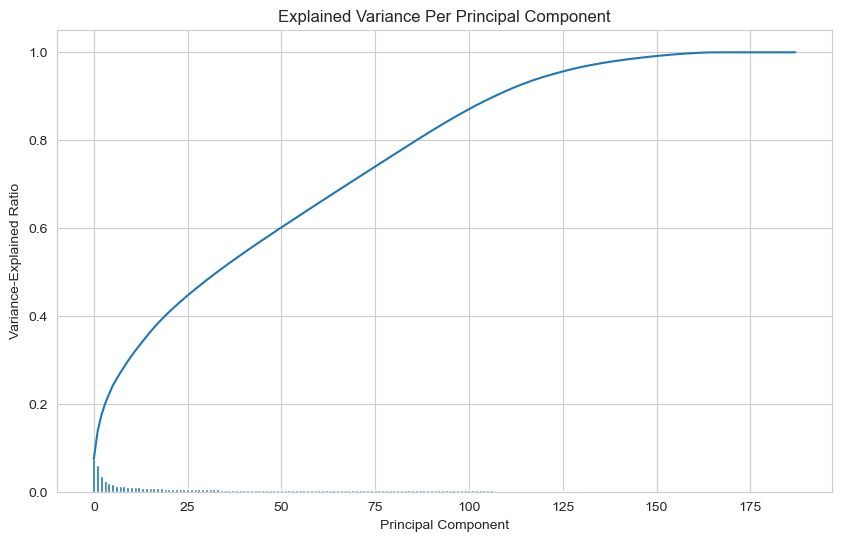

In [135]:
# Get the indexes
n_components = len(pca.explained_variance_ratio_)
component_idxs = np.arange(n_components)

# Get the explained variance ratios
variance_ratios = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))

# Get the cumulative sums
cumulative_variance = np.cumsum(variance_ratios)

# Scree Plot:
plt.bar(component_idxs, variance_ratios)
plt.plot(component_idxs, cumulative_variance)

plt.xlabel("Principal Component")
plt.ylabel("Variance-Explained Ratio")
plt.title('Explained Variance Per Principal Component')
plt.show()

In [136]:
# Determine number of components to reach 85% variance
# Chose 85% because we want to retain 80-90% of the information from the original data
n_components = 0

# iterate over the cumulative variances
for n in range(len(cumulative_variance)):
    # Stop when we reach 85 and print the value
    if cumulative_variance[n] * 100 >= 70:
        n_components = n
        break

print(f"Number of components to reach at least 70% variance: {n_components}")

Number of components to reach at least 70% variance: 68


In [137]:
# Re-apply PCA to the data while selecting for number of components to retain.
# Use random_state=42 to ensure reproducible results
pca_final = PCA(n_components=n_components, random_state=42)
X_pca = pca_final.fit_transform(df_pop_scaled)

In [138]:
print(f"X_pca.shape: {X_pca.shape}")
X_pca.head()

X_pca.shape: (797961, 68)


,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12,pca13,pca14,pca15,pca16,pca17,pca18,pca19,pca20,pca21,pca22,pca23,pca24,pca25,pca26,pca27,pca28,pca29,pca30,pca31,pca32,pca33,pca34,pca35,pca36,pca37,pca38,pca39,pca40,pca41,pca42,pca43,pca44,pca45,pca46,pca47,pca48,pca49,pca50,pca51,pca52,pca53,pca54,pca55,pca56,pca57,pca58,pca59,pca60,pca61,pca62,pca63,pca64,pca65,pca66,pca67
0,-5.136773,3.310263,3.134226,-0.461790,-0.646308,0.197461,-2.196242,2.130266,1.984876,0.527717,-1.900194,4.084152,2.671512,-3.783252,-0.533413,0.720095,0.646618,-1.988728,1.034369,-0.359725,-1.467842,-0.099352,1.344835,-2.510589,-0.146773,1.114429,2.114434,2.040450,2.633965,-0.037408,-1.744358,0.048692,-2.900396,-1.798263,-0.481241,-1.717921,-0.254167,0.756822,-0.153335,1.724403,-0.092096,0.257652,-1.100146,0.050845,0.365632,1.635266,-0.455854,0.399639,-2.411245,-0.813529,-2.282274,1.664395,-0.522390,1.631886,-0.578238,2.308795,-0.209951,1.089061,-1.555042,-0.988785,0.645848,1.489390,-0.168641,-0.845552,0.066502,-0.371793,0.565251,0.036957
1,0.069100,0.898673,3.156602,-1.858203,3.680316,-0.002225,-0.896375,-0.707785,-0.391641,-0.718721,0.390895,1.103897,-1.419861,0.043398,-0.391395,-0.994938,-1.848910,0.335153,-0.345290,-1.782918,-0.582641,-0.350166,0.115309,-1.779468,-0.322999,0.797395,-1.211927,-0.096480,-1.134771,0.192777,0.873070,-0.079233,-2.508034,0.830399,1.922346,0.164779,-0.587267,1.656444,-2.233674,0.089125,1.771048,0.246824,-0.958939,1.414841,-1.067767,-0.872920,-1.061950,0.412673,-0.139807,0.802965,-0.082567,-0.285625,-0.509320,0.989253,-0.786818,-0.505819,0.212105,0.606341,0.050565,-0.693174,-0.087896,0.369015,-0.158327,-0.534765,-0.045302,0.550276,-0.141543,0.119502
2,4.293001,-1.266060,1.440146,2.206440,-0.533907,3.088913,0.813445,0.197884,0.427617,0.177918,-0.385100,-2.193922,2.099355,0.333852,0.678618,0.661329,2.191188,0.911668,0.280318,-0.139924,-1.425256,2.411305,0.569269,-1.707492,-1.301907,1.174570,0.605602,-2.373766,-0.162295,0.753207,-1.264828,0.947910,-0.003228,0.201592,-0.009305,-0.852808,-0.653513,0.372626,-0.568229,0.002813,-0.191762,1.693458,1.091406,1.942507,-0.024527,1.098852,-1.843501,-1.064463,0.378501,-2.058709,0.029232,-2.018051,0.662061,-1.273191,-0.279483,-1.580047,-1.585996,-0.166265,0.679247,1.127129,-0.659989,-0.138159,1.428331,0.426869,-0.692446,2.617340,-0.312361,1.198510
3,0.133322,-0.260870,-3.145989,-1.803343,-3.319425,-0.600224,-0.651759,-1.965870,0.522105,-3.452149,-0.536305,1.297472,0.258594,2.216955,0.636203,-0.928680,-1.754532,1.924719,-0.324403,-1.377766,-0.027300,-0.669990,-0.978113,1.329372,-0.534521,-1.202935,-0.385010,0.853226,-0.001417,-0.974586,-0.249793,1.211143,-1.135559,0.884097,1.900723,-1.546297,-0.078897,0.819716,2.600007,-0.760652,1.567216,-0.164176,-1.199483,0.174993,1.443148,0.657480,-1.656382,0.496088,0.945551,0.337152,-0.112344,0.342320,0.259042,-0.609920,-0.484914,-0.398189,0.451099,-0.913016,0.060646,0.186780,-0.272753,-0.032342,0.162266,-0.082186,0.257920,-0.241187,-0.065285,-0.206194
4,0.772854,0.530242,0.958021,3.786661,1.935750,-0.054767,-2.005585,-0.745838,1.118612,-1.636720,0.788513,1.215885,-0.871817,0.448449,-1.986246,2.118399,0.171679,-1.904446,0.279723,2.006227,1.097648,-0.248913,-2.373022,1.270188,-0.847580,1.512992,0.440831,0.459107,1.599919,0.178872,0.330648,0.369019,2.442468,-1.008614,0.801905,0.952472,-0.421179,0.202018,1.068243,-0.458376,-0.466827,1.844354,0.842518,1.408810,0.576896,2.546140,-1.066126,-2.385012,1.412101,0.261591,0.694850,0.188676,-0.856436,0.528270,2.050867,0.679248,-2.328882,0.658209,-0.676413,-0.542838,-0.123222,0.028937,-1.089942,0.456890,-0.027775,0.654551,-0.034762,-0.433424


### Discussion 2.2: Perform Dimensionality Reduction

(Double-click this cell and replace this text with your own text, reporting your findings and decisions regarding dimensionality reduction. How many principal components / transformed features are you retaining for the next step of the analysis?)

### Step 2.3: Interpret Principal Components

Now that we have our transformed principal components, it's a nice idea to check out the weight of each variable on the first few components to see if they can be interpreted in some fashion.

As a reminder, each principal component is a unit vector that points in the direction of highest variance (after accounting for the variance captured by earlier principal components). The further a weight is from zero, the more the principal component is in the direction of the corresponding feature. If two features have large weights of the same sign (both positive or both negative), then increases in one tend expect to be associated with increases in the other. To contrast, features with different signs can be expected to show a negative correlation: increases in one variable should result in a decrease in the other.

- To investigate the features, you should map each weight to their corresponding feature name, then sort the features according to weight. The most interesting features for each principal component, then, will be those at the beginning and end of the sorted list. Use the data dictionary document to help you understand these most prominent features, their relationships, and what a positive or negative value on the principal component might indicate.
- You should investigate and interpret feature associations from the first three principal components in this substep. To help facilitate this, you should write a function that you can call at any time to print the sorted list of feature weights, for the *i*-th principal component. This might come in handy in the next step of the project, when you interpret the tendencies of the discovered clusters.

In [139]:
# Investigate a sample of the components
print(f"pca_f.components_.shape: {pca_final.components_.shape}")
pca_final.components_[:5, :10]

pca_f.components_.shape: (68, 188)


array([[-1.31907292e-02,  1.10496339e-01, -2.92932621e-02,
        -5.55111512e-17,  3.33066907e-16, -1.11022302e-16,
         1.38777878e-17, -1.10496339e-01,  4.25846676e-02,
         7.71882005e-02],
       [-3.89203630e-02,  2.85121253e-02, -2.41531312e-02,
        -1.11022302e-16, -1.11022302e-16,  2.22044605e-16,
        -1.38777878e-17, -2.85121253e-02,  2.53263525e-02,
        -1.97884934e-01],
       [ 3.48396234e-01, -6.28737726e-02,  8.09363219e-04,
        -8.32667268e-17, -2.16840434e-17,  8.32667268e-17,
        -1.38777878e-17,  6.28737726e-02,  4.34239677e-03,
        -2.06845755e-02],
       [-7.15551574e-02, -2.96463372e-01, -1.68074296e-02,
         0.00000000e+00,  0.00000000e+00,  6.66133815e-16,
        -3.33066907e-16,  2.96463372e-01, -5.60148167e-02,
         9.47797319e-02],
       [ 3.58553500e-02,  1.37350273e-01, -6.74295617e-03,
        -5.55111512e-17,  0.00000000e+00, -1.66533454e-16,
        -6.93889390e-18, -1.37350273e-01,  1.00308118e-01,
         1.

In [140]:
# Run this cell do clear prominent features dictionary
prominent_features = {0:{}, 1:{}, 2:{}}

In [141]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
# HINT: Try defining a function here or in a new cell that you can reuse in the
# other cells.
def map_component_weights(pca, df, pf_dict, pc_no, n_show=5):

    # Get the feature names and the weights
    feature_names = df.columns
    weights = pca.components_[pc_no]

    # Sanity Check
    assert len(feature_names) == len(weights)

    # Create a list of (feature_name, weight) tuples, sorted by weight from highest to lowest.
    weight_mapping = sorted(zip(feature_names, weights), key=lambda x: x[1], reverse=True)

    # We will only show the top and bottom values, given by n_show
    mapping_to_show = weight_mapping[:n_show] + weight_mapping[-n_show:]

    print(f"Printing mapping for PC{pc_no+1}, showing the {n_show} top and bottom: ")

    for feature, weight in mapping_to_show:

        # Add the information to the prominent features dictionary
        # for the given PC number and feature
        pf_dict[pc_no][feature] = weight.item()

        # Print results
        # Check if any of the engineered (to use the same description when printing)
        if feature in [C_WEALTH, C_LIFE]:
            idx = CAM_INT
        elif feature in [P_DECADE, P_MOVEMENT]:
            idx = PRA_JUG
        else:
            idx = feature

        try:
            print(f"Feature Name: {feature:<20} | {feature_dictionary[idx]["desc"][:50]:<50} | Weight: {weight:>8.4f}")
        # Handle errors when no valid key
        except KeyError:
            print(f"Feature Name: {feature:<20} | {" ":<50} | Weight: {weight:>8.4f}")

In [142]:
# Map weights for the first principal component to corresponding feature names
# and then print the linked values, sorted by weight.
map_component_weights(pca_final, df_pop_scaled, prominent_features, pc_no=0)

Printing mapping for PC1, showing the 5 top and bottom: 
Feature Name: FINANZ_MINIMALIST    | Financial typology: MINIMALIST (low financial inte | Weight:   0.2078
Feature Name: MOBI_REGIO           | Movement patterns                                  | Weight:   0.2075
Feature Name: KBA05_ANTG1          | Number of 1-2 family houses in the microcell (shar | Weight:   0.1920
Feature Name: PLZ8_ANTG1           | Number of 1-2 family houses in the PLZ8 region (sh | Weight:   0.1853
Feature Name: KBA05_GBZ            | Number of buildings in the microcell (category)    | Weight:   0.1827
Feature Name: ORTSGR_KLS9          | Size of community                                  | Weight:  -0.1558
Feature Name: PLZ8_ANTG4           | Number of 10+ family houses in the PLZ8 region (sh | Weight:  -0.1783
Feature Name: CAMEO_WEALTH         | German CAMEO: Wealth / Life Stage Typology, mapped | Weight:  -0.1827
Feature Name: PLZ8_ANTG3           | Number of 6-10 family houses in the PLZ8 region (s

In [143]:
# Map weights for the second principal component to corresponding feature names
# and then print the linked values, sorted by weight.
map_component_weights(pca_final, df_pop_scaled, prominent_features, pc_no=1)

Printing mapping for PC2, showing the 5 top and bottom: 
Feature Name: PRAEGENDE_DECADE     | Dominating movement of person's youth (avantgarde  | Weight:   0.2271
Feature Name: FINANZ_SPARER        | Financial typology: SPARER (money-saver)           | Weight:   0.2093
Feature Name: FINANZ_UNAUFFAELLIGER | Financial typology: UNAUFFAELLIGER (inconspicuous) | Weight:   0.2064
Feature Name: SEMIO_REL            | Personality typology: REL (religious)              | Weight:   0.1974
Feature Name: SEMIO_TRADV          | Personality typology: TRADV (traditional-minded)   | Weight:   0.1957
Feature Name: SEMIO_ERL            | Personality typology: ERL (event-oriented)         | Weight:  -0.1697
Feature Name: ZABEOTYP_3           |                                                    | Weight:  -0.1963
Feature Name: LP_AGE_CLASS         |                                                    | Weight:  -0.1979
Feature Name: FINANZ_VORSORGER     | Financial typology: VORSORGER (be prepared)      

In [144]:
# Map weights for the third principal component to corresponding feature names
# and then print the linked values, sorted by weight.
map_component_weights(pca_final, df_pop_scaled, prominent_features, pc_no=2)

Printing mapping for PC3, showing the 5 top and bottom: 
Feature Name: ANREDE_KZ            | Gender                                             | Weight:   0.3484
Feature Name: SEMIO_KAEM           | Personality typology: KAEM (combative attitude)    | Weight:   0.3198
Feature Name: SEMIO_DOM            | Personality typology: DOM (dominant-minded)        | Weight:   0.2881
Feature Name: SEMIO_KRIT           | Personality typology: KRIT (critical-minded)       | Weight:   0.2686
Feature Name: SEMIO_ERL            | Personality typology: ERL (event-oriented)         | Weight:   0.2115
Feature Name: FINANZTYP_5          |                                                    | Weight:  -0.1335
Feature Name: SEMIO_KULT           | Personality typology: KULT (cultural-minded)       | Weight:  -0.2551
Feature Name: SEMIO_SOZ            | Personality typology: SOZ (socially-minded)        | Weight:  -0.2593
Feature Name: SEMIO_FAM            | Personality typology: FAM (family-minded)         

In [145]:
print(f"Prominent Features: ")
pprint(prominent_features, compact=True)

Prominent Features: 
{0: {'CAMEO_WEALTH': -0.1826982701739247,
     'FINANZ_MINIMALIST': 0.2078203159214734,
     'HH_EINKOMMEN_SCORE': -0.18890419085162374,
     'KBA05_ANTG1': 0.19196016809864294,
     'KBA05_GBZ': 0.18270377444574107,
     'MOBI_REGIO': 0.207533033534721,
     'ORTSGR_KLS9': -0.1558257814387312,
     'PLZ8_ANTG1': 0.18528415205132856,
     'PLZ8_ANTG3': -0.18341370982492294,
     'PLZ8_ANTG4': -0.1782775464008173},
 1: {'ALTERSKATEGORIE_GROB': -0.2173770912342841,
     'FINANZ_SPARER': 0.2092913697691367,
     'FINANZ_UNAUFFAELLIGER': 0.20639328766006163,
     'FINANZ_VORSORGER': -0.20630452373741298,
     'LP_AGE_CLASS': -0.19788493377896418,
     'PRAEGENDE_DECADE': 0.2271460873419765,
     'SEMIO_ERL': -0.16966039885975187,
     'SEMIO_REL': 0.19741393244270314,
     'SEMIO_TRADV': 0.1956796721359992,
     'ZABEOTYP_3': -0.1963318156818707},
 2: {'ANREDE_KZ': 0.34839623423356547,
     'FINANZTYP_5': -0.13345507846691845,
     'SEMIO_DOM': 0.2881293160727497,
    

### Discussion 2.3: Interpret Principal Components

_"Since individual loadings are defined by a cosine function, they are limited to the range –1 (an angle of
rotation of 180◦ to +1 an angle of rotation of 0◦). The sign of the loading indicates how a variable
contributes to the principal component. A positive loading indicates that a variable contributes to some
degree to the principal component, and a negative loading indicates that its absence contributes to some
degree to the principal component. The larger a loading’s relative magnitude, the more important is its
presence or absence to the principal component."_

- https://cran.r-project.org/web/packages/LearnPCA/vignettes/Vig_04_Scores_Loadings.pdf

(Double-click this cell and replace this text with your own text, reporting your observations from detailed investigation of the first few principal components generated. Can we interpret positive and negative values from them in a meaningful way?)

## Step 3: Clustering

### Step 3.1: Apply Clustering to General Population

You've assessed and cleaned the demographics data, then scaled and transformed them. Now, it's time to see how the data clusters in the principal components space. In this substep, you will apply k-means clustering to the dataset and use the average within-cluster distances from each point to their assigned cluster's centroid to decide on a number of clusters to keep.

- Use sklearn's [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html#sklearn.cluster.KMeans) class to perform k-means clustering on the PCA-transformed data.
- Then, compute the average difference from each point to its assigned cluster's center. **Hint**: The KMeans object's `.score()` method might be useful here, but note that in sklearn, scores tend to be defined so that larger is better. Try applying it to a small, toy dataset, or use an internet search to help your understanding.
- Perform the above two steps for a number of different cluster counts. You can then see how the average distance decreases with an increasing number of clusters. However, each additional cluster provides a smaller net benefit. Use this fact to select a final number of clusters in which to group the data. **Warning**: because of the large size of the dataset, it can take a long time for the algorithm to resolve. The more clusters to fit, the longer the algorithm will take. You should test for cluster counts through at least 10 clusters to get the full picture, but you shouldn't need to test for a number of clusters above about 30.
- Once you've selected a final number of clusters to use, re-fit a KMeans instance to perform the clustering operation. Make sure that you also obtain the cluster assignments for the general demographics data, since you'll be using them in the final Step 3.3.

In [146]:
k_range = np.arange(2, 31)
inertias = [] # inertia (sum of squared distances to the closest cluster center)
scores = [] # score (negative inertia)
avg_distances = [] # intertia/number samples
silhouette_scores = []

# Over a number of different cluster counts...
for k in k_range:
    # run k-means clustering on the data and...
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_pca)
    sil_score = silhouette_score(X_pca, labels, sample_size=20000, random_state=42)
    silhouette_scores.append(sil_score)

    # compute the average within-cluster distances.
    inertias.append(model.inertia_)

    avg_distance = model.inertia_ / len(X_pca)
    avg_distances.append(avg_distance)

    score = model.score(X_pca)
    scores.append(score)

    print(f"For {k}: score: {score:.4f}, inertia: {model.inertia_:.4f}, avg distance: {avg_distance}, silhouette_score: {sil_score:.4f}")

For 2: score: -93919603.7357, inertia: 93919603.7357, avg distance: 117.69949124799055, silhouette_score: 0.0812
For 3: score: -89156324.2234, inertia: 89156324.2234, avg distance: 111.73017756936316, silhouette_score: 0.0666
For 4: score: -87750911.8896, inertia: 87750911.8896, avg distance: 109.96892315490787, silhouette_score: 0.0552
For 5: score: -84778235.0095, inertia: 84778235.0095, avg distance: 106.24358209177429, silhouette_score: 0.0500
For 6: score: -83314009.7038, inertia: 83314009.7038, avg distance: 104.40862360911761, silhouette_score: 0.0498
For 7: score: -81553076.9930, inertia: 81553076.9930, avg distance: 102.20183316348954, silhouette_score: 0.0545
For 8: score: -80698430.3246, inertia: 80698430.3246, avg distance: 101.1307950195127, silhouette_score: 0.0508
For 9: score: -78112617.3395, inertia: 78112617.3395, avg distance: 97.89026949880216, silhouette_score: 0.0478
For 10: score: -77535055.2037, inertia: 77535055.2037, avg distance: 97.16647205023492, silhouette

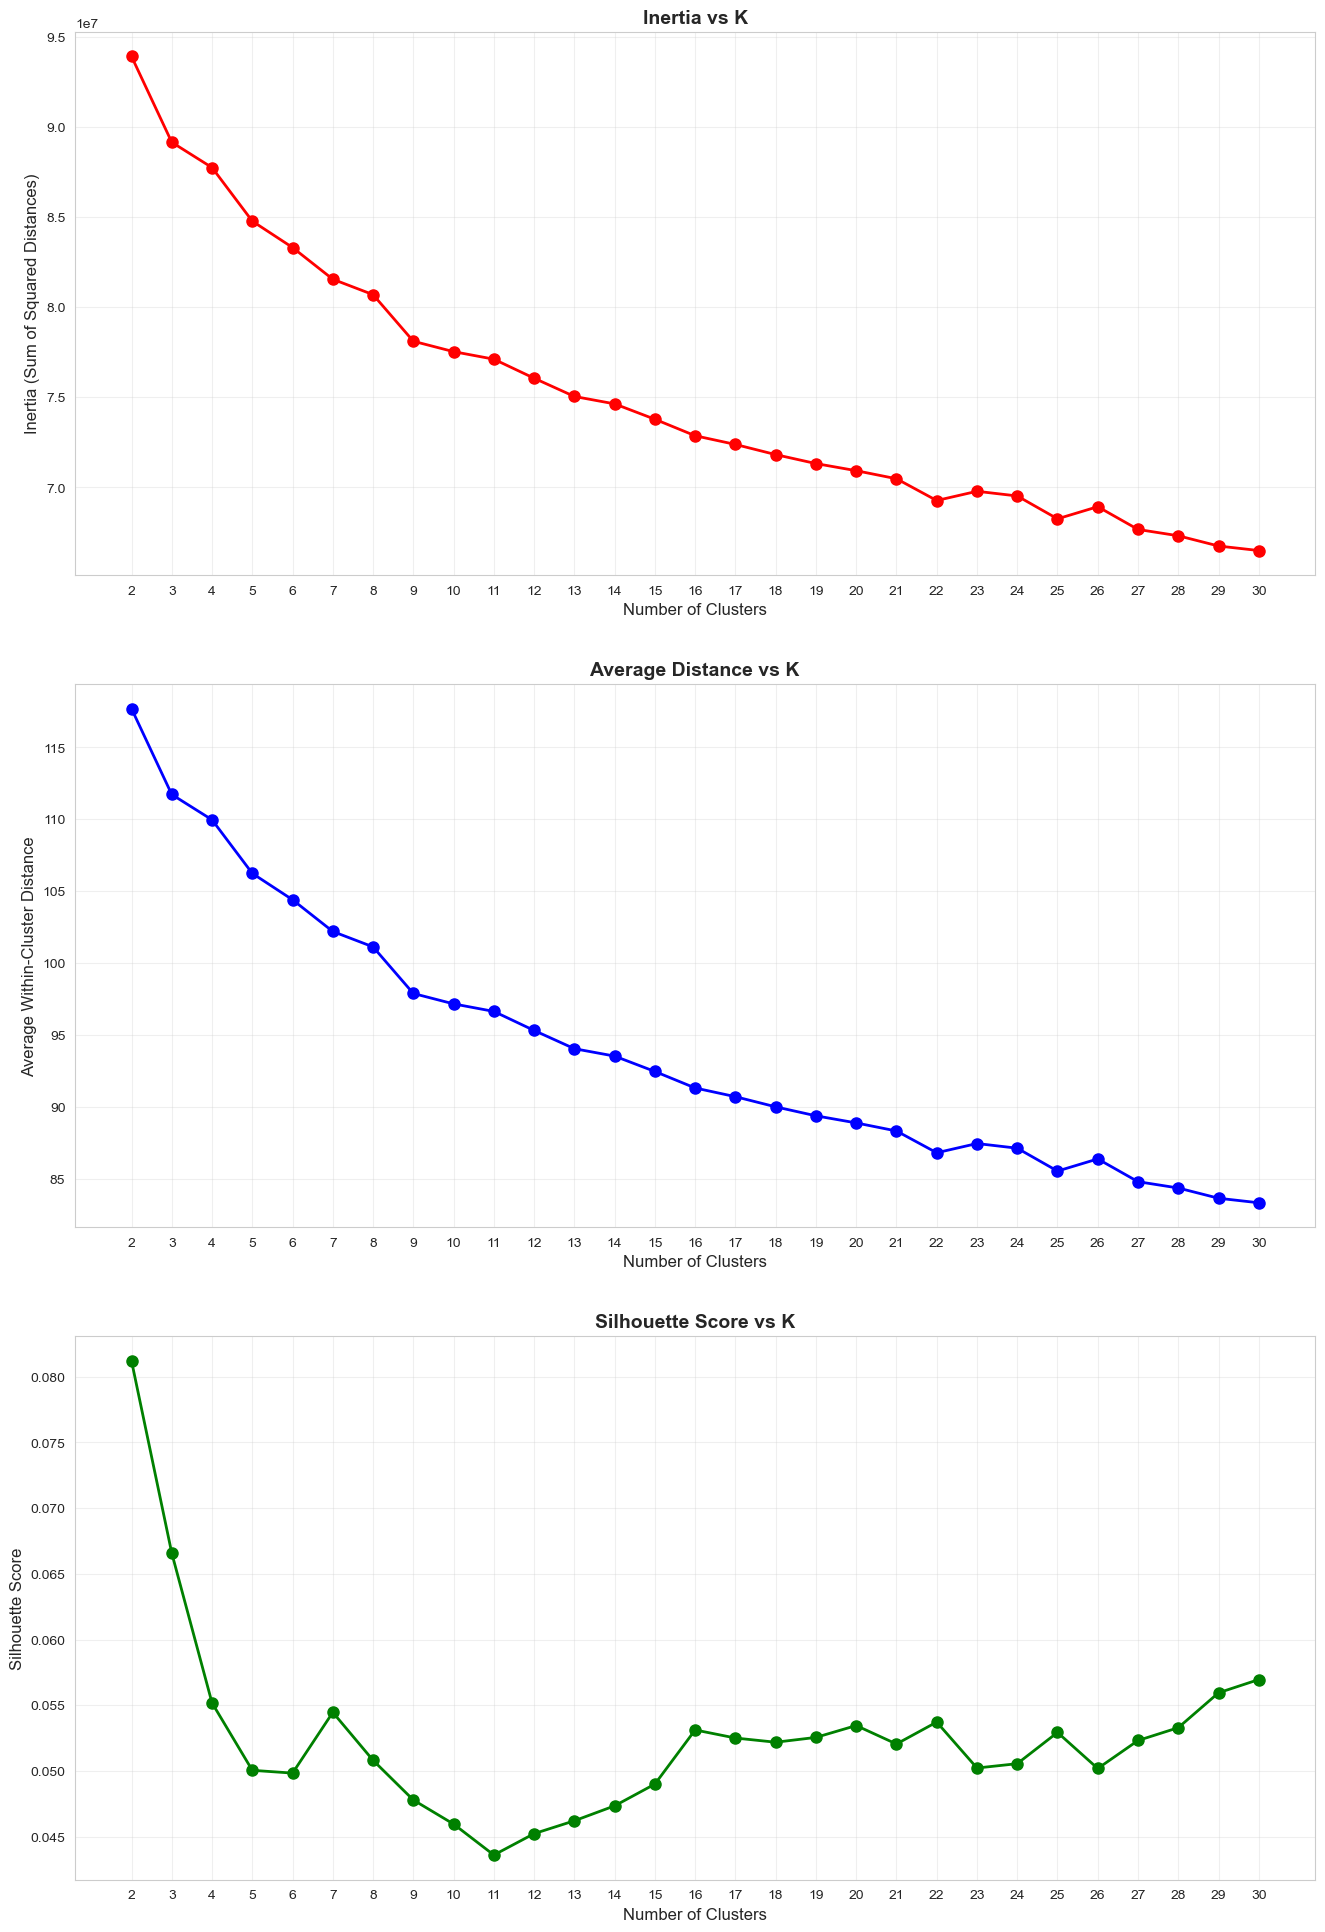

In [150]:
# Investigate the change in within-cluster distance across number of clusters.
# HINT: Use matplotlib's plot function to visualize this relationship.

fig, ax = plt.subplots(3, 1, figsize=(16, 24))

# Plot 1: Inertia
ax[0].plot(k_range, inertias, 'ro-', linewidth=2, markersize=8)
ax[0].set_xlabel('Number of Clusters', fontsize=12)
ax[0].set_ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
ax[0].set_title('Inertia vs K', fontsize=14, fontweight='bold')
ax[0].set_xticks(k_range)
ax[0].grid(True, alpha=0.3)

# Plot 2: Average Distance
ax[1].plot(k_range, avg_distances, 'bo-', linewidth=2, markersize=8)
ax[1].set_xlabel('Number of Clusters', fontsize=12)
ax[1].set_ylabel('Average Within-Cluster Distance', fontsize=12)
ax[1].set_title('Average Distance vs K', fontsize=14, fontweight='bold')
ax[1].set_xticks(k_range)
ax[1].grid(True, alpha=0.3)

# Plot 3: Silhouette Score
ax[2].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax[2].set_xlabel('Number of Clusters', fontsize=12)
ax[2].set_ylabel('Silhouette Score', fontsize=12)
ax[2].set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
ax[2].set_xticks(k_range)
ax[2].grid(True, alpha=0.3)

plt.show()

In [151]:
# Re-fit the k-means model with the selected number of clusters and obtain
# cluster predictions for the general population demographics data.
model_7 = KMeans(n_clusters=7).fit(X_pca)
population_clusters = model_7.predict(X_pca)
population_clusters

array([1, 1, 2, ..., 4, 0, 6], shape=(797961,), dtype=int32)

### Discussion 3.1: Apply Clustering to General Population

(Double-click this cell and replace this text with your own text, reporting your findings and decisions regarding clustering. Into how many clusters have you decided to segment the population?)

### Step 3.2: Apply All Steps to the Customer Data

Now that you have clusters and cluster centers for the general population, it's time to see how the customer data maps on to those clusters. Take care to not confuse this for re-fitting all of the models to the customer data. Instead, you're going to use the fits from the general population to clean, transform, and cluster the customer data. In the last step of the project, you will interpret how the general population fits apply to the customer data.

- Don't forget when loading in the customers data, that it is semicolon (`;`) delimited.
- Apply the same feature wrangling, selection, and engineering steps to the customer demographics using the `clean_data()` function you created earlier. (You can assume that the customer demographics data has similar meaning behind missing data patterns as the general demographics data.)
- Use the sklearn objects from the general demographics data, and apply their transformations to the customers data. That is, you should not be using a `.fit()` or `.fit_transform()` method to re-fit the old objects, nor should you be creating new sklearn objects! Carry the data through the feature scaling, PCA, and clustering steps, obtaining cluster assignments for all of the data in the customer demographics data.

In [175]:
# Load in the customer demographics data.
customers_raw = pd.read_csv(DATA_CUSTOMERS, delimiter=';')
customers_raw.head()

,AGER_TYP,ALTERSKATEGORIE_GROB,ANREDE_KZ,CJT_GESAMTTYP,FINANZ_MINIMALIST,FINANZ_SPARER,FINANZ_VORSORGER,FINANZ_ANLEGER,FINANZ_UNAUFFAELLIGER,FINANZ_HAUSBAUER,FINANZTYP,GEBURTSJAHR,GFK_URLAUBERTYP,GREEN_AVANTGARDE,HEALTH_TYP,LP_LEBENSPHASE_FEIN,LP_LEBENSPHASE_GROB,LP_FAMILIE_FEIN,LP_FAMILIE_GROB,LP_STATUS_FEIN,LP_STATUS_GROB,NATIONALITAET_KZ,PRAEGENDE_JUGENDJAHRE,RETOURTYP_BK_S,SEMIO_SOZ,SEMIO_FAM,SEMIO_REL,SEMIO_MAT,SEMIO_VERT,SEMIO_LUST,SEMIO_ERL,SEMIO_KULT,SEMIO_RAT,SEMIO_KRIT,SEMIO_DOM,SEMIO_KAEM,SEMIO_PFLICHT,SEMIO_TRADV,SHOPPER_TYP,SOHO_KZ,TITEL_KZ,VERS_TYP,ZABEOTYP,ALTER_HH,ANZ_PERSONEN,ANZ_TITEL,HH_EINKOMMEN_SCORE,KK_KUNDENTYP,W_KEIT_KIND_HH,WOHNDAUER_2008,ANZ_HAUSHALTE_AKTIV,ANZ_HH_TITEL,GEBAEUDETYP,KONSUMNAEHE,MIN_GEBAEUDEJAHR,OST_WEST_KZ,WOHNLAGE,CAMEO_DEUG_2015,CAMEO_DEU_2015,CAMEO_INTL_2015,KBA05_ANTG1,KBA05_ANTG2,KBA05_ANTG3,KBA05_ANTG4,KBA05_BAUMAX,KBA05_GBZ,BALLRAUM,EWDICHTE,INNENSTADT,GEBAEUDETYP_RASTER,KKK,MOBI_REGIO,ONLINE_AFFINITAET,REGIOTYP,KBA13_ANZAHL_PKW,PLZ8_ANTG1,PLZ8_ANTG2,PLZ8_ANTG3,PLZ8_ANTG4,PLZ8_BAUMAX,PLZ8_HHZ,PLZ8_GBZ,ARBEIT,ORTSGR_KLS9,RELAT_AB
0,2,4,1,5.0,5,1,5,1,2,2,2,0,4.0,1,1,20.0,5.0,2.0,2.0,10.0,5.0,1,4,5.0,6,5,2,6,6,7,3,4,1,3,1,1,2,1,3,0.0,0.0,1,3,10.0,2.0,0.0,1.0,NaN,6.0,9.0,1.0,0.0,1.0,5.0,1992.0,W,7.0,1,1A,13,2.0,2.0,0.0,0.0,0.0,4.0,3.0,2.0,4.0,4.0,1.0,4.0,3.0,1.0,1201.0,3.0,3.0,1.0,0.0,1.0,5.0,5.0,1.0,2.0,1.0
1,-1,4,1,NaN,5,1,5,1,3,2,2,0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,1,0,NaN,3,6,2,6,7,5,3,4,1,3,3,2,4,1,3,0.0,0.0,1,3,11.0,3.0,0.0,NaN,NaN,0.0,9.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-1,4,2,2.0,5,1,5,1,4,4,2,0,3.0,1,2,13.0,3.0,1.0,1.0,10.0,5.0,1,4,5.0,2,2,1,3,3,7,7,1,2,7,5,6,4,1,1,0.0,0.0,2,3,6.0,1.0,0.0,1.0,NaN,6.0,9.0,1.0,0.0,8.0,1.0,1992.0,W,2.0,5,5D,34,2.0,2.0,0.0,0.0,0.0,3.0,7.0,4.0,1.0,3.0,3.0,3.0,1.0,7.0,433.0,2.0,3.0,3.0,1.0,3.0,3.0,2.0,3.0,5.0,3.0
3,1,4,1,2.0,5,1,5,2,1,2,6,0,10.0,0,2,0.0,0.0,0.0,0.0,9.0,4.0,1,1,3.0,6,5,3,4,7,5,3,4,3,3,3,3,3,4,0,0.0,0.0,1,1,8.0,0.0,0.0,4.0,NaN,NaN,9.0,0.0,NaN,2.0,2.0,1992.0,W,7.0,4,4C,24,3.0,0.0,0.0,0.0,1.0,4.0,7.0,1.0,7.0,4.0,3.0,4.0,2.0,6.0,755.0,3.0,2.0,1.0,0.0,1.0,3.0,4.0,1.0,3.0,1.0
4,-1,3,1,6.0,3,1,4,4,5,2,2,1960,2.0,0,3,31.0,10.0,10.0,5.0,1.0,1.0,1,8,5.0,4,5,4,6,5,6,4,5,5,3,5,2,5,4,1,0.0,0.0,2,1,20.0,4.0,0.0,6.0,2.0,2.0,9.0,7.0,0.0,3.0,1.0,1992.0,W,3.0,7,7B,41,0.0,3.0,2.0,0.0,0.0,3.0,3.0,4.0,4.0,3.0,4.0,3.0,5.0,7.0,513.0,2.0,4.0,2.0,1.0,2.0,3.0,3.0,3.0,5.0,1.0


In [176]:
print(type(feature_summary))

<class 'pandas.core.frame.DataFrame'>


In [177]:
print(feature_summary.columns.tolist())
print(repr(FS_ATTR))

['attribute', 'information_level', 'type', 'missing_or_unknown']
'attribute'


In [178]:
# Apply preprocessing, feature transformation, and clustering from the general
# demographics onto the customer data, obtaining cluster predictions for the
# customer demographics data.
customers_clean, customers_high_missing = clean_data(
    df=customers_raw,
    fs=feature_summary,
    fg=feature_groups,
    m=mappings,
    return_both_subsets=True
)
customers_clean.head()

Cleaning Data..... 

[Pipeline]  (step 1 of 9) Processing replace_missing_values, total=   0.4s
Dropping Features: ['TITEL_KZ', 'AGER_TYP', 'KK_KUNDENTYP', 'KBA05_BAUMAX', 'GEBURTSJAHR', 'ALTER_HH']
Number of features dropped: 6
[Pipeline] .. (step 2 of 9) Processing drop_na_features, total=   0.2s
[Pipeline] ........ (step 3 of 9) Processing split_data, total=   0.1s
[Pipeline] ..... (step 4 of 9) Processing re_encode_owz, total=   0.0s
[Pipeline]  (step 5 of 9) Processing re_encode_categoricals, total=   0.2s


ValueError: Length mismatch: Expected axis has 193 elements, new values have 189 elements

In [ ]:
customers_high_missing.head()

In [ ]:
# Apply the same imputing and scaling
customers_imputed = imputer.transform(customers_clean)
customers_scaled = customers_imputed.copy()
customers_scaled[feature_groups[TO_SCALE]] =  scaler.transform(customers_scaled[feature_groups[TO_SCALE]])
customers_scaled.head()

In [ ]:
# Apply PCA and Clustering
customers_pca = pca_final.transform(customers_scaled)
customer_clusters = model_10.predict(customers_pca)
customer_clusters

### Step 3.3: Compare Customer Data to Demographics Data

At this point, you have clustered data based on demographics of the general population of Germany, and seen how the customer data for a mail-order sales company maps onto those demographic clusters. In this final substep, you will compare the two cluster distributions to see where the strongest customer base for the company is.

Consider the proportion of persons in each cluster for the general population, and the proportions for the customers. If we think the company's customer base to be universal, then the cluster assignment proportions should be fairly similar between the two. If there are only particular segments of the population that are interested in the company's products, then we should see a mismatch from one to the other. If there is a higher proportion of persons in a cluster for the customer data compared to the general population (e.g. 5% of persons are assigned to a cluster for the general population, but 15% of the customer data is closest to that cluster's centroid) then that suggests the people in that cluster to be a target audience for the company. On the other hand, the proportion of the data in a cluster being larger in the general population than the customer data (e.g. only 2% of customers closest to a population centroid that captures 6% of the data) suggests that group of persons to be outside of the target demographics.

Take a look at the following points in this step:

- Compute the proportion of data points in each cluster for the general population and the customer data. Visualizations will be useful here: both for the individual dataset proportions, but also to visualize the ratios in cluster representation between groups. Seaborn's [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) or [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) function could be handy.
  - Recall the analysis you performed in step 1.1.3 of the project, where you separated out certain data points from the dataset if they had more than a specified threshold of missing values. If you found that this group was qualitatively different from the main bulk of the data, you should treat this as an additional data cluster in this analysis. Make sure that you account for the number of data points in this subset, for both the general population and customer datasets, when making your computations!
- Which cluster or clusters are overrepresented in the customer dataset compared to the general population? Select at least one such cluster and infer what kind of people might be represented by that cluster. Use the principal component interpretations from step 2.3 or look at additional components to help you make this inference. Alternatively, you can use the `.inverse_transform()` method of the PCA and StandardScaler objects to transform centroids back to the original data space and interpret the retrieved values directly.
- Perform a similar investigation for the underrepresented clusters. Which cluster or clusters are underrepresented in the customer dataset compared to the general population, and what kinds of people are typified by these clusters?

Reference: https://knowledge.udacity.com/questions/905904

In [ ]:
# Calculate proportions
population_proportions = pd.Series(population_clusters).value_counts(normalize=True).sort_index()
customer_proportions = pd.Series(customer_clusters).value_counts(normalize=True).sort_index()

In [ ]:
# Plot
width = 0.35
cluster_indexes = np.arange(0, len(np.unique(population_clusters).tolist()))

plt.bar(cluster_indexes - width/2, population_proportions, width, color='r', label='General')
plt.bar(cluster_indexes + width/2, customer_proportions, width,  color='b' , label='Customer')

plt.xlabel('Cluster')
plt.ylabel('Proportion')

plt.title('Cluster Proportions of General Population and Customers')

plt.xticks(cluster_indexes, np.unique(population_clusters).tolist())
plt.legend(loc='upper left')

plt.grid()
plt.show()

In [ ]:
# Plot 2: Difference (Customer % - Population %)
difference = [c - p for c, p in zip(customer_proportions, population_proportions)]
colors = ['g' if x > 0 else 'r' for x in difference]

plt.bar(cluster_indexes, difference, color=colors, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Difference (Customer % - Population %)', fontsize=12)
plt.title('Overrepresented (Green) vs Underrepresented (Red) Clusters', fontsize=14, fontweight='bold')

plt.xticks(cluster_indexes)
# plt.xticklabels(np.unique(population_clusters))
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

over_represented_clusters = []

# Print detailed comparison
print("Cluster Analysis:")
print("=" * 70)
for i in cluster_indexes:
    diff = difference[i]

    representation = "OVERREPRESENTED" if diff > 0 else "UNDERREPRESENTED"

    print(f"Cluster {i}: Pop={population_proportions[i]:.2%}, "
          f"Cust={customer_proportions[i]:.2%}, "
          f"Diff={diff:+.2%} {representation}")

In [ ]:
# From the chart above, we select the 3 overrepresented and 3 underrepresented clusters
over_represented_clusters = [8, 3, 1]
under_represented_clusters = [6, 9, 2]

In [ ]:
df_cluster_centroids_scaled = pca_final.inverse_transform(model_10.cluster_centers_)
df_cluster_centroids_scaled = pd.DataFrame(df_cluster_centroids_scaled, columns=customers_scaled.columns)
df_cluster_centroids_scaled.head(10)

In [ ]:
df_overrep_scaled = df_cluster_centroids_scaled.iloc[over_represented_clusters]
df_underrep_scaled = df_cluster_centroids_scaled.iloc[under_represented_clusters]

In [ ]:
# Inverse scaling
df_overrep = df_overrep_scaled.copy()
df_underrep = df_underrep_scaled.copy()

df_overrep[feature_groups[TO_SCALE]] = scaler.inverse_transform(df_overrep[feature_groups[TO_SCALE]])
df_underrep[feature_groups[TO_SCALE]] = scaler.inverse_transform(df_underrep[feature_groups[TO_SCALE]])

In [ ]:
prominent_features_list = [
    feature
    for feature_dict in prominent_features.values()
    for i, feature in enumerate(feature_dict.keys()) if i in [0, 1, 2, 7, 8, 9]
]
prominent_features_list

In [ ]:
# What kinds of people are part of a cluster that is overrepresented in the
# customer data compared to the general population?
df_overrep[prominent_features_list].head()

In [ ]:
# What kinds of people are part of a cluster that is underrepresented in the
# customer data compared to the general population?
df_underrep[prominent_features_list].head()

### Discussion 3.3: Compare Customer Data to Demographics Data

(Double-click this cell and replace this text with your own text, reporting findings and conclusions from the clustering analysis. Can we describe segments of the population that are relatively popular with the mail-order company, or relatively unpopular with the company?)

> Congratulations on making it this far in the project! Before you finish, make sure to check through the entire notebook from top to bottom to make sure that your analysis follows a logical flow and all of your findings are documented in **Discussion** cells. Once you've checked over all of your work, you should export the notebook as an HTML document to submit for evaluation. You can do this from the menu, navigating to **File -> Download as -> HTML (.html)**. You will submit both that document and this notebook for your project submission.